# XÂY DỰNG MÔ HÌNH GỢI Ý CHẾ ĐỘ DINH DƯỠNG BẰNG KNN

Dự án tập trung xây dựng hệ thống gợi ý dinh dưỡng cá nhân hóa dựa trên bộ dữ liệu Final Food Dataset (Kaggle) gồm 37 thuộc tính, nổi bật với 34 chỉ số dinh dưỡng chi tiết từ đa lượng đến vi lượng. Bằng việc áp dụng thuật toán K-Nearest Neighbors (KNN) trong khung bài toán Hệ gợi ý dựa trên nội dung (Content-based Filtering), mô hình sẽ thực hiện tính toán khoảng cách toán học giữa nhu cầu người dùng và đặc trưng thực phẩm trong không gian 34 chiều. Từ đó, hệ thống tự động truy xuất và đề xuất những thực đơn có độ tương đồng cao nhất, giúp tối ưu hóa mục tiêu sức khỏe và cá nhân hóa chế độ dinh dưỡng cho từng đối tượng sử dụng.

#1.Thiết lập môi trường

##1.1: Cài đặt thư viện (Pip install)
Mục tiêu: Đảm bảo môi trường có đầy đủ các "vũ khí" tối tân nhất cho Machine Learning.

In [1]:
#Cài đặt các thư viện bổ sung không có sẵn mặc định trên Colab
!pip install -q shap xgboost lightgbm joblib
print("Cài đặt thư viện hoàn tất.")

Cài đặt thư viện hoàn tất.


##1.2: Kết nối Google Drive & Tạo thư mục dự án
Mục tiêu: Quản lý dữ liệu tập trung, tránh việc mất dữ liệu khi tắt trình duyệt.

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Định nghĩa đường dẫn dự án (Bạn có thể đổi tên thư mục tùy ý)
PROJECT_DIR = '/content/drive/MyDrive/DoAn2_DinhDuong'

if not os.path.exists(PROJECT_DIR):
    os.makedirs(PROJECT_DIR)
    print(f"Đã tạo thư mục dự án tại: {PROJECT_DIR}")
else:
    print(f"Thư mục dự án đã sẵn sàng tại: {PROJECT_DIR}")

# Di chuyển vào thư mục dự án
os.chdir(PROJECT_DIR)

Mounted at /content/drive
Đã tạo thư mục dự án tại: /content/drive/MyDrive/DoAn2_DinhDuong


##1.3: Import toàn bộ thư viện
Mục tiêu: Khai báo tất cả công cụ cần thiết một lần duy nhất để tránh lỗi "NameError" sau này.

In [4]:
# Xử lý dữ liệu
import pandas as pd
import numpy as np
import time
from datetime import datetime

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Machine Learning - Tiền xử lý & Chia tách
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
import xgboost as xgb


# Đánh giá & Lưu trữ
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib

print("Import thư viện thành công.")

Import thư viện thành công.


##1.4: Cấu hình hệ thống (CONFIG Dict)
Mục tiêu: Quản lý tập trung các tham số. Khi muốn đổi tên file hay đổi tỷ lệ chia dữ liệu, bạn chỉ cần sửa ở đây.

In [5]:
CONFIG = {
    "DATA_PATH": "FOOD-DATA-GROUP1.csv",
    "TARGET_COL": "Caloric Value",
    "TEST_SIZE": 0.2,
    "RANDOM_STATE": 42,
    "SAVE_MODELS": True,
    "FIG_SIZE": (12, 8),
    "EXPORT_DIR": "./exports",
    "IMG_DIR": "./images"
}

# Tạo thư mục lưu ảnh và file xuất nếu chưa có
for folder in [CONFIG["EXPORT_DIR"], CONFIG["IMG_DIR"]]:
    if not os.path.exists(folder):
        os.makedirs(folder)

print("Cấu hình CONFIG đã được thiết lập.")

Cấu hình CONFIG đã được thiết lập.


##1.5: Các hàm bổ trợ (Helper Functions)
Mục tiêu: Tự động hóa các tác vụ lặp đi lặp lại, giúp code chính trở nên cực kỳ gọn gàng.

In [6]:
# 1. Hàm lưu biểu đồ tự động
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(CONFIG["IMG_DIR"], f"{fig_id}.{fig_extension}")
    print(f"Đang lưu biểu đồ: {fig_id}...")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 2. Hàm tóm tắt dữ liệu thông minh
def df_summary(df):
    summary = pd.DataFrame({
        'Kiểu dữ liệu': df.dtypes,
        'Giá trị thiếu (Null)': df.isnull().sum(),
        '% Thiếu': (df.isnull().sum() / len(df)) * 100,
        'Giá trị duy nhất': df.nunique(),
        'Giá trị mẫu': df.iloc[0]
    })
    return summary

# 3. Hàm đo thời gian thực thi
class Timer:
    def __enter__(self):
        self.start = time.perf_counter()
        return self

    def __exit__(self, *args):
        self.end = time.perf_counter()
        self.interval = self.end - self.start
        print(f"Thời gian thực thi: {self.interval:.4f} giây")

print("Các hàm Helper đã sẵn sàng.")

Các hàm Helper đã sẵn sàng.


##1.6: Xác nhận môi trường (Version Check)
Mục tiêu: Kiểm tra phiên bản để đảm bảo tính tương thích khi triển khai lên Web sau này.

In [7]:
import sklearn
import platform

print(f"Hệ điều hành: {platform.system()} {platform.release()}")
print(f"Phiên bản Python: {platform.python_version()}")
print(f"Phiên bản Pandas: {pd.__version__}")
print(f"Phiên bản Scikit-learn: {sklearn.__version__}")
print(f"Thời gian khởi tạo: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n--- MÔI TRƯỜNG ĐÃ SẴN SÀNG ---")

Hệ điều hành: Linux 6.6.113+
Phiên bản Python: 3.12.13
Phiên bản Pandas: 2.2.2
Phiên bản Scikit-learn: 1.6.1
Thời gian khởi tạo: 2026-04-10 11:16:41

--- MÔI TRƯỜNG ĐÃ SẴN SÀNG ---


# 2.Đọc dữ liệu - Kiểm tra sơ bộ

## 2.1. Tự động nhận diện định dạng và đọc file

In [9]:
def load_data(path):
    ext = os.path.splitext(path)[1].lower()
    try:
        if ext == '.csv':
            return pd.read_csv(path, encoding='utf-8', sep=',')
        elif ext in ['.xls', '.xlsx']:
            return pd.read_excel(path)
        else:
            print(f"Định dạng {ext} không hỗ trợ.")
            return None
    except Exception as e:
        print(f"Lỗi khi đọc file: {e}")
        # Thử lại với encoding khác nếu lỗi
        return pd.read_csv(path, encoding='latin1')

df = load_data(CONFIG["DATA_PATH"])
print(f"Đã tải dữ liệu từ: {CONFIG['DATA_PATH']}")

Đã tải dữ liệu từ: FOOD-DATA-GROUP1.csv


In [ ]:
# Hiển thị 5 dòng dữ liệu đầu tiên để quan sát cấu trúc
print("DANH SÁCH 5 DÒNG DỮ LIỆU ĐẦU TIÊN:")
display(df.head())

DANH SÁCH 5 DÒNG DỮ LIỆU ĐẦU TIÊN:


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007


##2.2a: Xem Head / Middle / Tail

In [10]:
# 2.2a. Kiểm tra tính nhất quán ở đầu, giữa và cuối file
print("--- 5 Dòng đầu ---")
display(df.head())
print("\n--- 5 Dòng giữa ---")
display(df.sample(5))
print("\n--- 5 Dòng cuối ---")
display(df.tail())

--- 5 Dòng đầu ---


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,cream cheese,51,5.0,2.9,1.3,0.200,0.8,0.500,...,0.008,14.100,0.082,0.027,1.300,0.091,15.5,19.100,0.039,7.070
1,1,1,neufchatel cheese,215,19.4,10.9,4.9,0.800,3.1,2.700,...,99.500,0.034,0.100,8.500,0.088,117.300,129.2,0.054,0.700,130.100
2,2,2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,0.000,0.9,3.400,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,5.400
3,3,3,ricotta cheese,30,2.0,1.3,0.5,0.002,1.5,0.091,...,0.097,41.200,0.097,0.096,4.000,0.024,30.8,43.800,0.035,5.196
4,4,4,cream cheese low fat,30,2.3,1.4,0.6,0.042,1.2,0.900,...,22.200,0.072,0.008,1.200,0.098,22.800,37.1,0.034,0.053,27.007



--- 5 Dòng giữa ---


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
291,291,291,hotcakes mcdonalds,113,2.9,0.6,0.6,1.5,19.0,4.4,...,41.700,0.054,0.900,9.4,0.100,129.0,85.8,0.000,0.200,68.200
512,512,512,squid fried,140,6.0,1.5,2.2,1.7,6.2,0.0,...,31.200,1.700,0.800,30.4,0.046,200.8,223.2,0.087,1.400,62.028
328,328,328,hamburger,255,9.9,3.5,3.7,1.3,28.7,5.8,...,0.068,112.500,0.027,2.8,21.300,0.2,106.7,191.100,0.017,53.859
171,171,171,pasta with sliced franks in tomato sauce,227,6.0,2.5,2.5,1.0,32.0,8.0,...,151.200,0.300,2.300,35.3,0.300,108.4,481.3,0.020,1.300,216.154
258,258,258,sausage mcgriddles mcdonalds,421,24.0,7.3,10.2,3.5,42.2,15.2,...,85.100,0.100,1.900,18.9,0.300,426.6,195.8,0.000,1.000,166.000



--- 5 Dòng cuối ---


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
546,546,546,chinook salmon smoked,159,5.9,1.300,2.800,1.400,0.0,0.0,...,15.0,0.300,1.2,24.5,0.055,223.0,238.0,0.027,0.400,47.038
547,547,547,cisco smoked,50,3.4,0.500,1.600,0.600,0.0,0.0,...,7.4,0.015,0.1,4.8,0.047,42.5,82.9,0.050,0.076,15.576
548,548,548,haddock smoked,33,0.3,0.049,0.006,0.055,0.0,0.0,...,13.9,0.001,0.4,15.3,0.075,71.0,117.4,0.063,0.100,21.719
549,549,549,whitefish smoked,147,1.3,0.300,0.400,0.400,0.0,0.0,...,24.5,0.400,0.7,31.3,0.091,179.5,575.3,0.030,0.700,58.398
550,550,550,red salmon sockeye filets smoked,373,12.3,2.800,4.300,3.700,0.0,0.0,...,62.6,0.200,1.1,62.6,0.048,702.0,1036.8,0.026,1.200,141.587


##2.2b: Liệt kê toàn bộ cột & Giá trị mẫu

In [11]:
col_info = pd.DataFrame({
    'Cột': df.columns,
    'Kiểu dữ liệu': df.dtypes,
    'Giá trị mẫu': df.iloc[0].values
})
display(col_info)

,Cột,Kiểu dữ liệu,Giá trị mẫu
Unnamed: 0.1,Unnamed: 0.1,int64,0
Unnamed: 0,Unnamed: 0,int64,0
food,food,object,cream cheese
Caloric Value,Caloric Value,int64,51
Fat,Fat,float64,5.0
Saturated Fats,Saturated Fats,float64,2.9
Monounsaturated Fats,Monounsaturated Fats,float64,1.3
Polyunsaturated Fats,Polyunsaturated Fats,float64,0.2
Carbohydrates,Carbohydrates,float64,0.8
Sugars,Sugars,float64,0.5


##2.2c: Tổng quan nhanh về bộ nhớ và giá trị Null


In [12]:
print("CẤU TRÚC DỮ LIỆU TỔNG QUÁT:")
df.info()

CẤU TRÚC DỮ LIỆU TỔNG QUÁT:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          551 non-null    int64  
 1   Unnamed: 0            551 non-null    int64  
 2   food                  551 non-null    object 
 3   Caloric Value         551 non-null    int64  
 4   Fat                   551 non-null    float64
 5   Saturated Fats        551 non-null    float64
 6   Monounsaturated Fats  551 non-null    float64
 7   Polyunsaturated Fats  551 non-null    float64
 8   Carbohydrates         551 non-null    float64
 9   Sugars                551 non-null    float64
 10  Protein               551 non-null    float64
 11  Dietary Fiber         551 non-null    float64
 12  Cholesterol           551 non-null    float64
 13  Sodium                551 non-null    float64
 14  Water                 551 non-null    float64


## 2.3. Thống kê số học (mở rộng percentiles) và phân loại (categorical)

In [13]:
print("THỐNG KÊ CÁC CỘT SỐ (MỞ RỘNG):")
display(df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

print("\nTHỐNG KÊ CÁC CỘT CHỮ (CATEGORICAL):")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f"\nGiá trị phổ biến ở cột '{col}':")
    print(df[col].value_counts().head(5))

THỐNG KÊ CÁC CỘT SỐ (MỞ RỘNG):


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Unnamed: 0.1,551.0,275.000000,159.204271,0.000,5.5000,27.5000,137.5000,275.000,412.5000,522.500,544.5000,550.0
Unnamed: 0,551.0,275.000000,159.204271,0.000,5.5000,27.5000,137.5000,275.000,412.5000,522.500,544.5000,550.0
Caloric Value,551.0,237.359347,199.235598,3.000,8.0000,25.5000,94.5000,186.000,337.0000,585.000,887.5000,1578.0
Fat,551.0,10.766933,12.544196,0.000,0.0355,0.2500,2.5000,6.600,14.4000,35.000,59.2000,87.5
Saturated Fats,551.0,3.722715,5.397021,0.000,0.0000,0.0205,0.5000,1.800,4.8000,12.700,25.1500,43.5
Monounsaturated Fats,551.0,4.001564,5.540608,0.000,0.0000,0.0240,0.6000,2.200,5.1500,13.700,31.1500,48.0
Polyunsaturated Fats,551.0,2.170793,3.470820,0.000,0.0000,0.0095,0.4000,1.100,2.6000,7.950,14.1000,40.1
Carbohydrates,551.0,15.819036,20.289320,0.000,0.0000,0.0000,0.0000,5.100,28.7000,51.850,83.4500,128.3
Sugars,551.0,2.708907,7.455666,0.000,0.0000,0.0000,0.0000,0.000,2.2000,12.250,45.6000,70.8
Protein,551.0,18.417857,18.932404,0.000,0.0000,1.2000,5.3000,11.900,25.6500,65.450,80.9000,86.9



THỐNG KÊ CÁC CỘT CHỮ (CATEGORICAL):

Giá trị phổ biến ở cột 'food':
food
red salmon sockeye filets smoked    1
cream cheese                        1
neufchatel cheese                   1
requeijao cremoso light catupiry    1
ricotta cheese                      1
Name: count, dtype: int64


##2.4: Phân tích dữ liệu thiếu (Missing Values)

Đang lưu biểu đồ: missing_matrix...


/tmp/ipykernel_36074/1454865851.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x400 with 0 Axes>

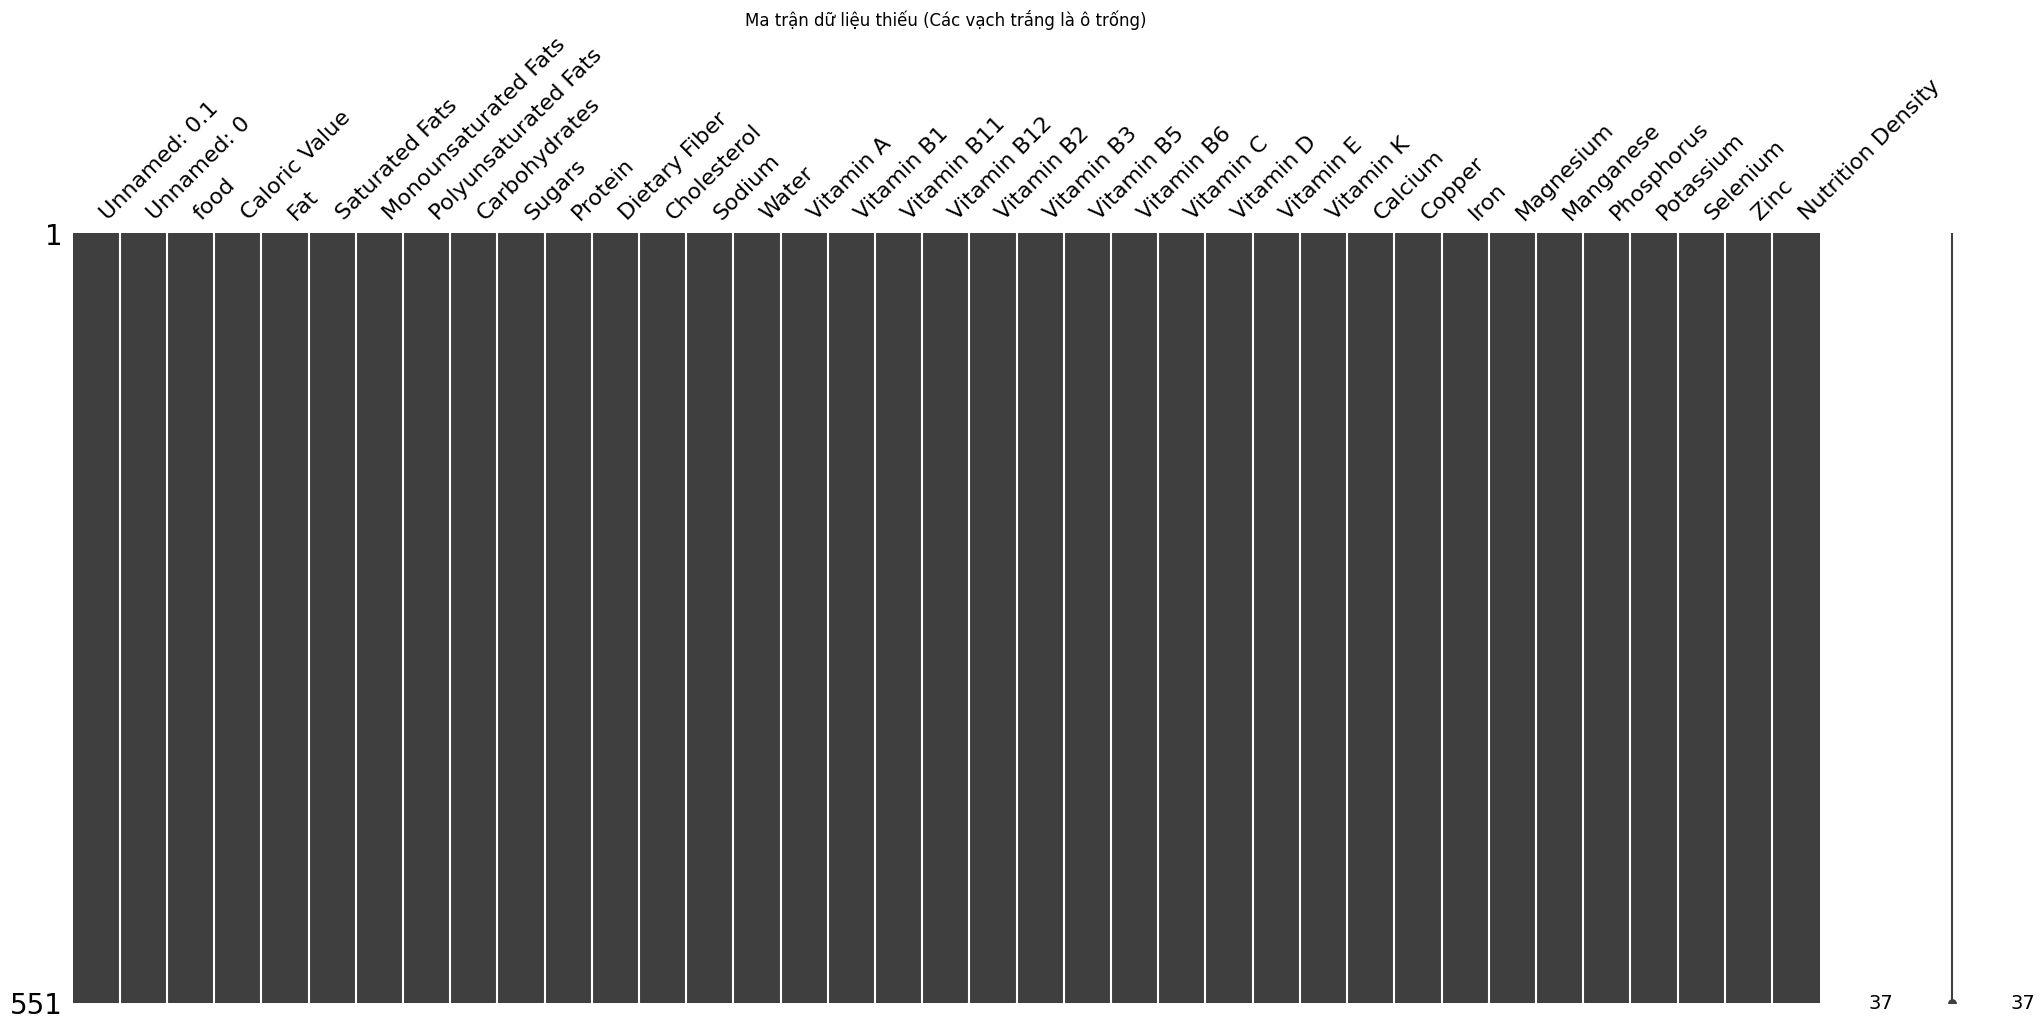

Không có giá trị thiếu nào trong dữ liệu.


In [17]:
import missingno as msno

# 2.4. Trực quan hóa khoảng trống dữ liệu
plt.figure(figsize=(10, 4))
msno.matrix(df)
plt.title("Ma trận dữ liệu thiếu (Các vạch trắng là ô trống)")
save_fig("missing_matrix")
plt.show()

# Bar chart chi tiết
missing_counts = df.isnull().sum()
# Chỉ vẽ biểu đồ nếu có giá trị thiếu
if not missing_counts[missing_counts > 0].empty:
    missing_counts[missing_counts > 0].plot(kind='bar', figsize=(12,5), color='orange')
    plt.title("Số lượng giá trị thiếu theo từng cột")
    plt.show()
else:
    print("Không có giá trị thiếu nào trong dữ liệu.")

##2.5: Kiểm tra dữ liệu trùng lặp (Duplicates)

In [18]:
# 2.5. Đếm và hiển thị các dòng bị lặp
duplicate_count = df.duplicated().sum()
print(f"Số lượng dòng trùng lặp hoàn toàn: {duplicate_count}")

if duplicate_count > 0:
    print("Ví dụ các dòng bị trùng:")
    display(df[df.duplicated()].head())

Số lượng dòng trùng lặp hoàn toàn: 0


##2.6: Tự động phát hiện vấn đề (Auto-detect)

In [19]:
# 2.6. Tìm kiếm các điểm bất thường
print("KIỂM TRA CÁC VẤN ĐỀ TIỀM ẨN:")

# 1. Cột dạng object nhưng lẽ ra là số
potential_numeric = []
for col in df.select_dtypes(include=['object']).columns:
    if df[col].str.isnumeric().sum() > len(df) * 0.5:
        potential_numeric.append(col)
print(f"- Cột chữ nghi ngờ là số: {potential_numeric}")

# 2. Giá trị âm ở các cột dinh dưỡng (vô lý)
numeric_cols = df.select_dtypes(include=[np.number]).columns
negative_check = (df[numeric_cols] < 0).sum()
print(f"- Các cột có giá trị âm (nghi ngờ lỗi): \n{negative_check[negative_check > 0]}")

KIỂM TRA CÁC VẤN ĐỀ TIỀM ẨN:
- Cột chữ nghi ngờ là số: []
- Các cột có giá trị âm (nghi ngờ lỗi): 
Series([], dtype: int64)


##2.7: Phân tích biến mục tiêu (Target Column)

Đang lưu biểu đồ: target_analysis...


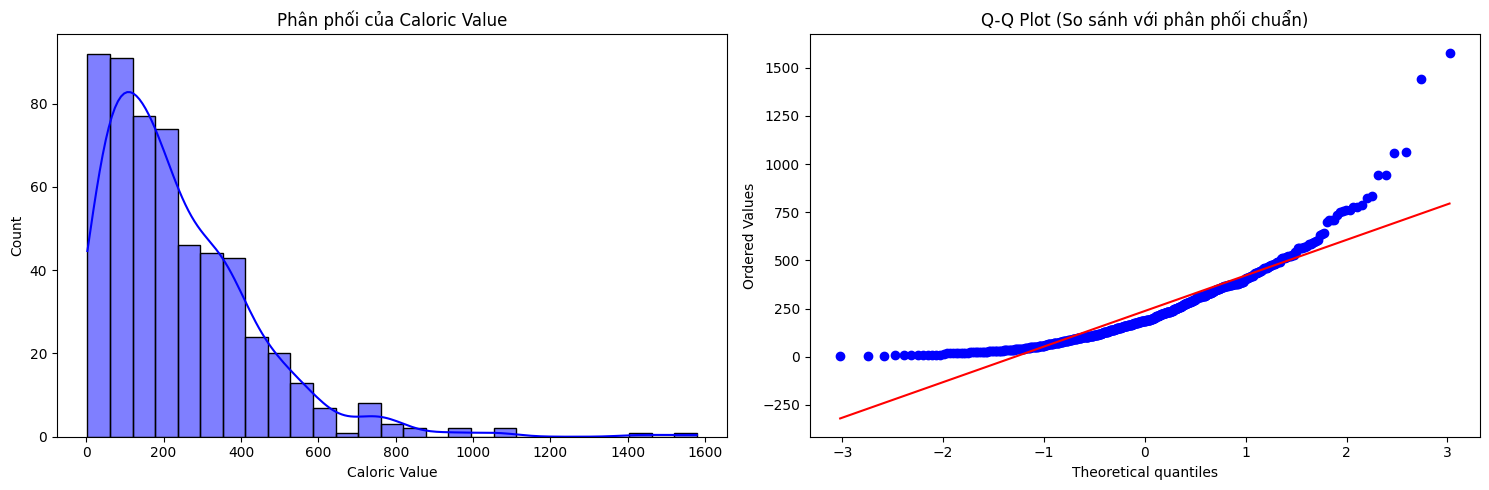

In [20]:
from scipy import stats

# 2.7. Phân tích cột Caloric Value
target = CONFIG["TARGET_COL"]
plt.figure(figsize=(15, 5))

# Distribution plot
plt.subplot(1, 2, 1)
sns.histplot(df[target], kde=True, color='blue')
plt.title(f"Phân phối của {target}")

# Q-Q plot (Kiểm tra phân phối chuẩn)
plt.subplot(1, 2, 2)
stats.probplot(df[target], plot=plt)
plt.title("Q-Q Plot (So sánh với phân phối chuẩn)")

save_fig("target_analysis")
plt.show()

##2.8: Xuất bản tóm tắt dữ liệu

In [21]:
# 2.8. Sử dụng hàm helper đã tạo ở Bước 1 để lưu tóm tắt
summary = df_summary(df)
summary.to_csv(os.path.join(CONFIG["EXPORT_DIR"], "data_inspection_summary.csv"))
print("Đã lưu bản tóm tắt dữ liệu vào thư mục exports.")
display(summary)

Đã lưu bản tóm tắt dữ liệu vào thư mục exports.


,Kiểu dữ liệu,Giá trị thiếu (Null),% Thiếu,Giá trị duy nhất,Giá trị mẫu
Unnamed: 0.1,int64,0,0.0,551,0
Unnamed: 0,int64,0,0.0,551,0
food,object,0,0.0,551,cream cheese
Caloric Value,int64,0,0.0,338,51
Fat,float64,0,0.0,235,5.0
Saturated Fats,float64,0,0.0,162,2.9
Monounsaturated Fats,float64,0,0.0,171,1.3
Polyunsaturated Fats,float64,0,0.0,116,0.2
Carbohydrates,float64,0,0.0,260,0.8
Sugars,float64,0,0.0,118,0.5


##2.9: Checkpoint & Ghi chú TODO

In [23]:
# 2.9. Tổng kết trạng thái dữ liệu
print("--- CHECKPOINT BƯỚC 2 ---")
print(f"1. Tổng số bản ghi: {df.shape[0]}")
print(f"2. Tổng số thuộc tính: {df.shape[1]}")
print(f"3. Tình trạng dữ liệu thiếu: {'Có' if df.isnull().values.any() else 'Không'}")
print(f"4. Tình trạng trùng lặp: {'Có' if duplicate_count > 0 else 'Không'}")

print("\n--- DANH SÁCH CẦN LÀM (TODO) CHO BƯỚC 3 ---")
print(" [ ] Xử lý các giá trị âm ở cột dinh dưỡng (nếu có)")
print(" [ ] Chuyển đổi kiểu dữ liệu cho các cột nghi ngờ")
print(" [ ] Loại bỏ các cột ID hoặc cột không có giá trị dự báo")

--- CHECKPOINT BƯỚC 2 ---
1. Tổng số bản ghi: 551
2. Tổng số thuộc tính: 37
3. Tình trạng dữ liệu thiếu: Không
4. Tình trạng trùng lặp: Không

--- DANH SÁCH CẦN LÀM (TODO) CHO BƯỚC 3 ---
 [ ] Xử lý các giá trị âm ở cột dinh dưỡng (nếu có)
 [ ] Chuyển đổi kiểu dữ liệu cho các cột nghi ngờ
 [ ] Loại bỏ các cột ID hoặc cột không có giá trị dự báo


#3.EDA - Phân tích dữ liệu

##3.1: Phân loại cột tự động

In [24]:
# 3.1. Tự động phân loại các nhóm cột
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Phân loại sâu hơn trong nhóm số
continuous_cols = [col for col in num_cols if df[col].nunique() > 25]
discrete_cols = [col for col in num_cols if df[col].nunique() <= 25]

print(f"LOG PHÂN LOẠI:")
print(f"- Cột liên tục (Continuous): {len(continuous_cols)}")
print(f"- Cột rời rạc (Discrete): {len(discrete_cols)}")
print(f"- Cột phân loại (Categorical): {len(cat_cols)}")

LOG PHÂN LOẠI:
- Cột liên tục (Continuous): 36
- Cột rời rạc (Discrete): 0
- Cột phân loại (Categorical): 1


##3.2a: Histogram + KDE (Toàn bộ cột số)

Đang lưu biểu đồ: 03_hist_numerical...


/tmp/ipykernel_36074/1454865851.py:6: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_36074/1454865851.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(path, format=fig_extension, dpi=resolution)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


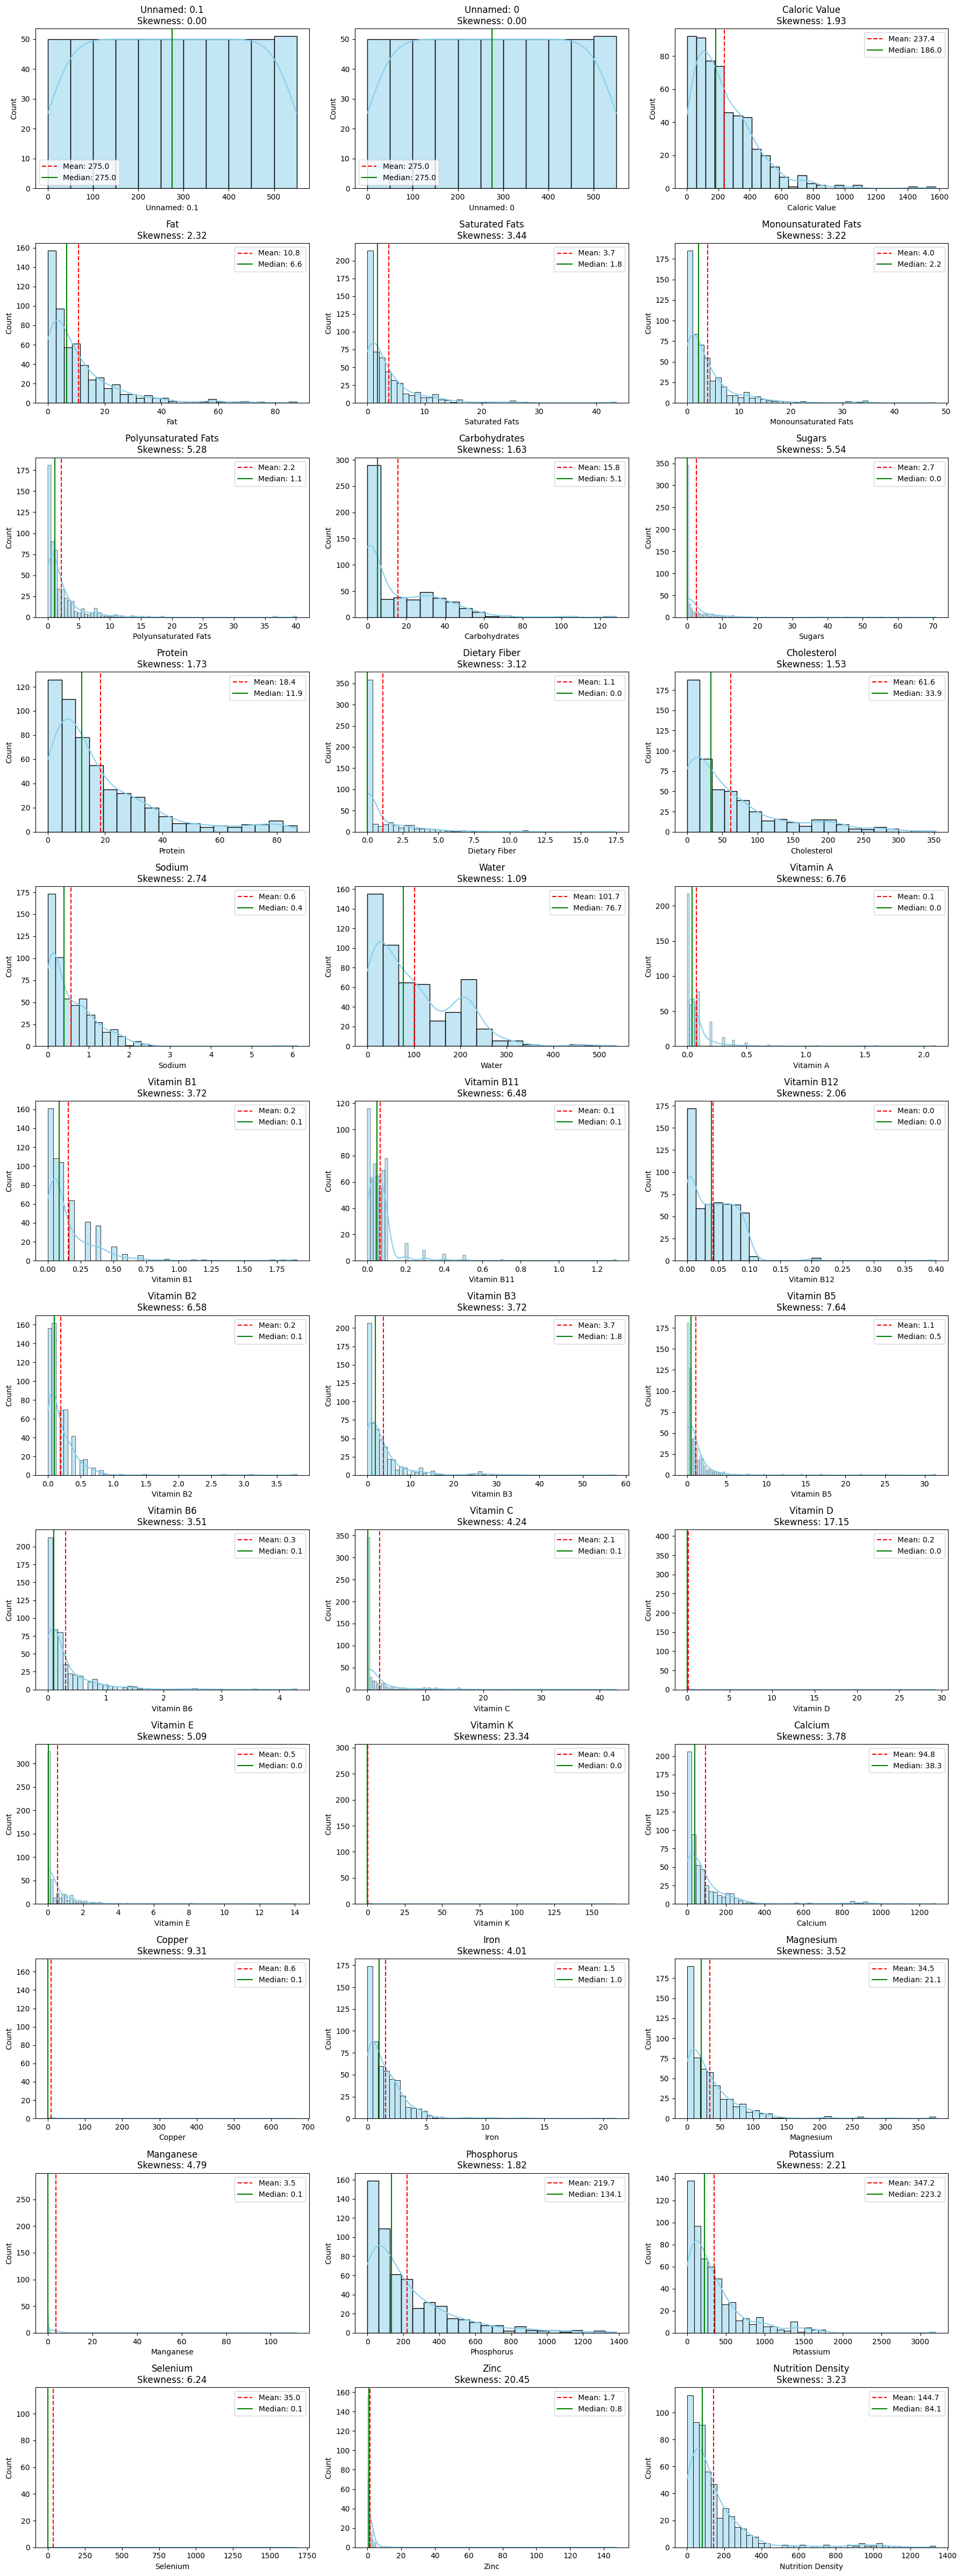

In [25]:
# 3.2a. Vẽ phân phối cho các cột số liên tục
n_cols = 3
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    mean_val, median_val = df[col].mean(), df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f}')
    axes[i].set_title(f"{col}\nSkewness: {df[col].skew():.2f}")
    axes[i].legend()

# Xóa các ô thừa
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
save_fig("03_hist_numerical")
plt.show()

##3.2b: Boxplot & Outlier Detection

Đang lưu biểu đồ: 03_boxplot_outliers...


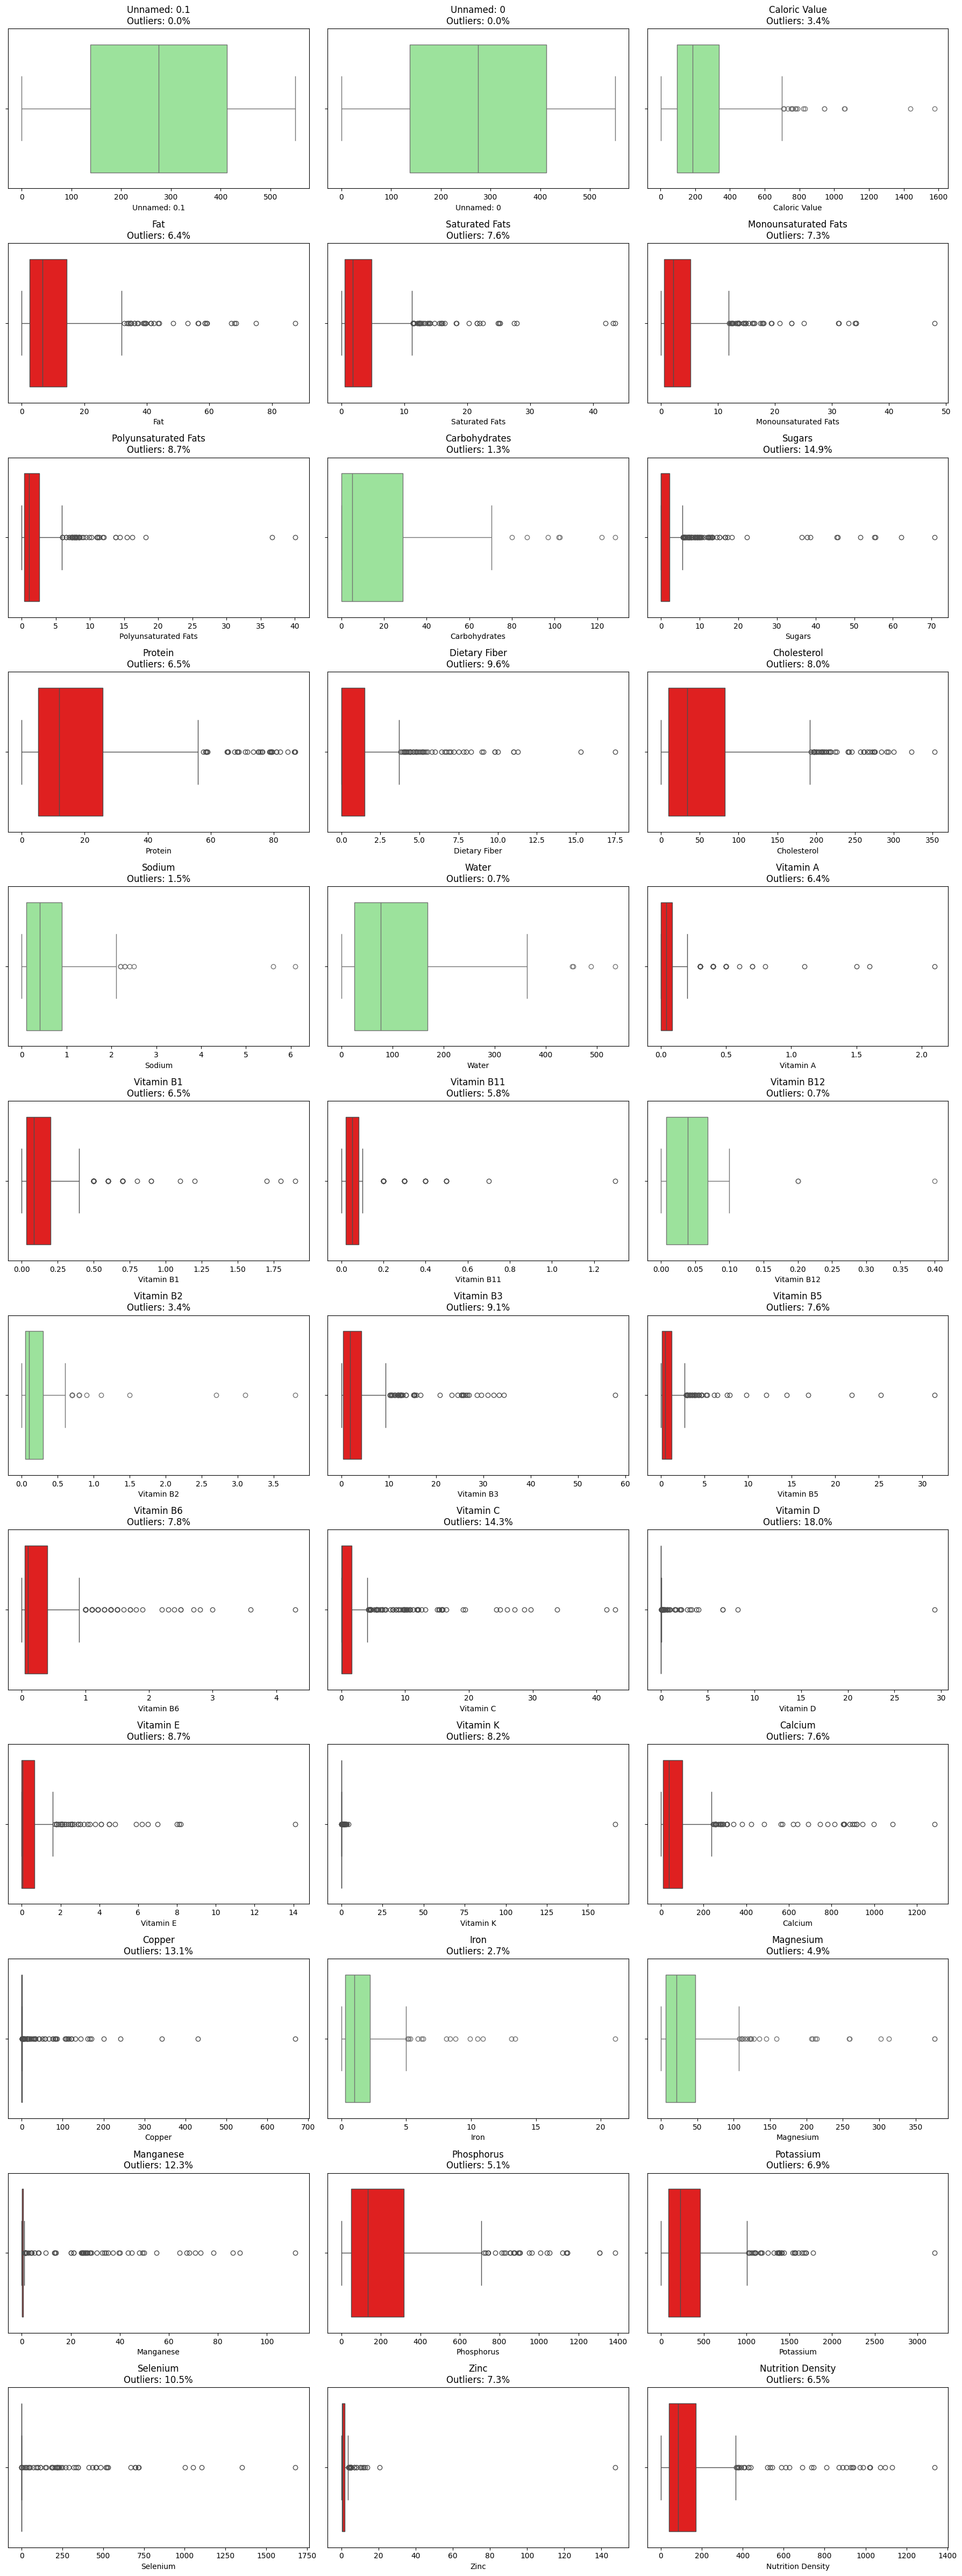

In [26]:
# 3.2b. Vẽ Boxplot và tô đỏ nếu Outlier > 5%
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

outlier_report = []

for i, col in enumerate(continuous_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    outlier_pct = len(outliers) / len(df) * 100

    color = 'red' if outlier_pct > 5 else 'lightgreen'
    sns.boxplot(x=df[col], ax=axes[i], color=color)
    axes[i].set_title(f"{col}\nOutliers: {outlier_pct:.1f}%")
    outlier_report.append({'Cột': col, 'Outlier %': outlier_pct, 'IQR': IQR})

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
save_fig("03_boxplot_outliers")
plt.show()

##3.2c: Bảng thống kê Outlier chi tiết

In [28]:
# 3.2c. Bảng thống kê Outlier với Gradient màu
outlier_df = pd.DataFrame(outlier_report)
display(outlier_df.style.background_gradient(cmap='Reds', subset=['Outlier %']))

,Cột,Outlier %,IQR
0,Unnamed: 0.1,0.000000,275.000000
1,Unnamed: 0,0.000000,275.000000
2,Caloric Value,3.448276,242.500000
3,Fat,6.352087,11.900000
4,Saturated Fats,7.622505,4.300000
5,Monounsaturated Fats,7.259528,4.550000
6,Polyunsaturated Fats,8.711434,2.200000
7,Carbohydrates,1.270417,28.700000
8,Sugars,14.882033,2.200000
9,Protein,6.533575,20.350000


##3.3: Bar chart cho cột Categorical

/tmp/ipykernel_36074/29058813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, palette='viridis')


Đang lưu biểu đồ: 03_cat_food...


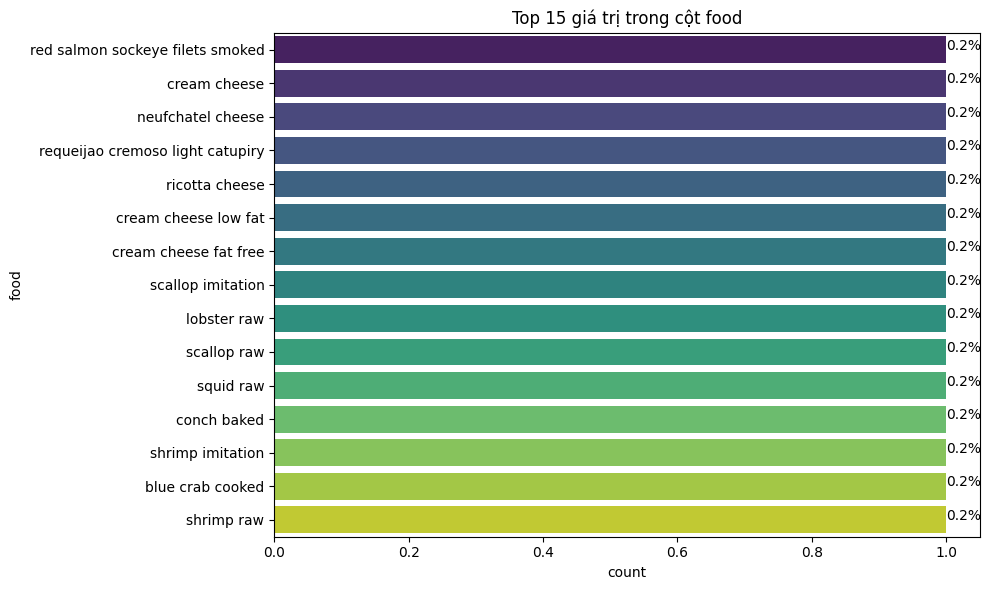

In [29]:
# 3.3. Phân tích các cột chữ (Top 15)
for col in cat_cols:
    if df[col].nunique() > 1:
        plt.figure(figsize=(10, 6))
        order = df[col].value_counts().iloc[:15].index
        sns.countplot(y=df[col], order=order, palette='viridis')

        # Thêm % vào đầu thanh
        total = len(df[col])
        for i, p in enumerate(plt.gca().patches):
            percentage = f'{100 * p.get_width() / total:.1f}%'
            plt.gca().annotate(percentage, (p.get_width(), p.get_y() + p.get_height()/2), ha='left')

        plt.title(f"Top 15 giá trị trong cột {col}")
        save_fig(f"03_cat_{col}")
        plt.show()

##3.4a: Heatmap Correlation

Đang lưu biểu đồ: 03_correlation_heatmap...


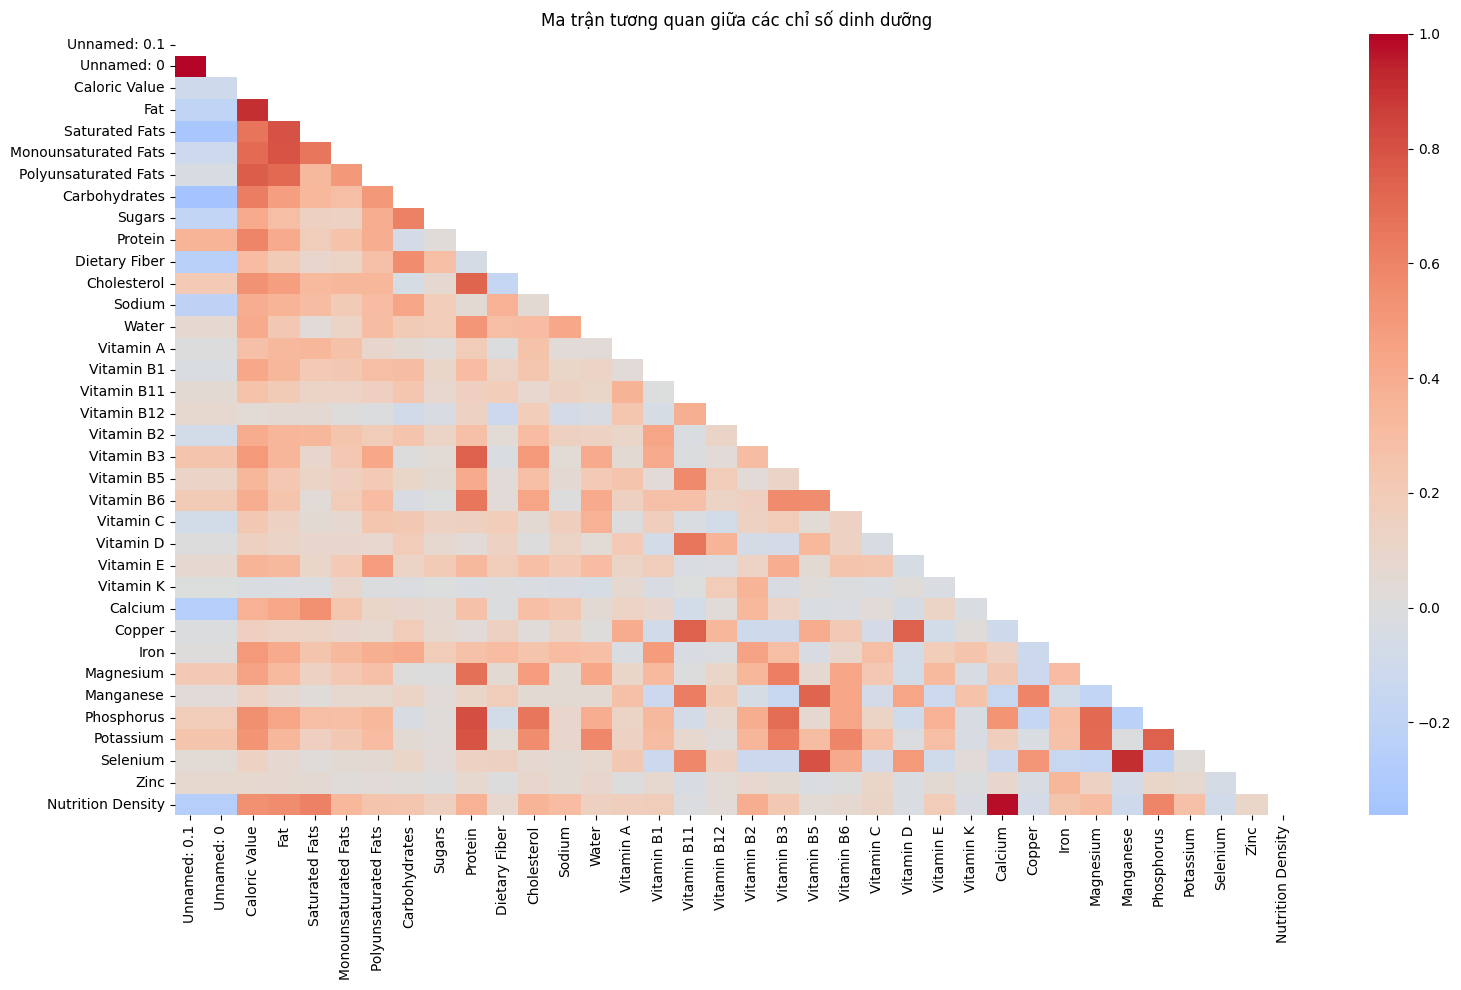

CÁC CẶP TƯƠNG QUAN MẠNH:
Nutrition Density  Calcium              0.979534
Calcium            Nutrition Density    0.979534
Manganese          Selenium             0.914781
Selenium           Manganese            0.914781
Fat                Caloric Value        0.909024
Caloric Value      Fat                  0.909024
Phosphorus         Protein              0.809509
Protein            Phosphorus           0.809509
Selenium           Vitamin B5           0.800319
Vitamin B5         Selenium             0.800319
dtype: float64


In [30]:
# 3.4a. Ma trận tương quan tam giác dưới
plt.figure(figsize=(16, 10))
corr = df[continuous_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0)
plt.title("Ma trận tương quan giữa các chỉ số dinh dưỡng")
save_fig("03_correlation_heatmap")
plt.show()

# Liệt kê các cặp tương quan mạnh (>0.7)
high_corr = corr.unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.7) & (high_corr < 1.0)]
print("CÁC CẶP TƯƠNG QUAN MẠNH:")
print(high_corr.head(10))

##3.4b: Tương quan với Target (Calories)

Đang lưu biểu đồ: 03_target_correlation...


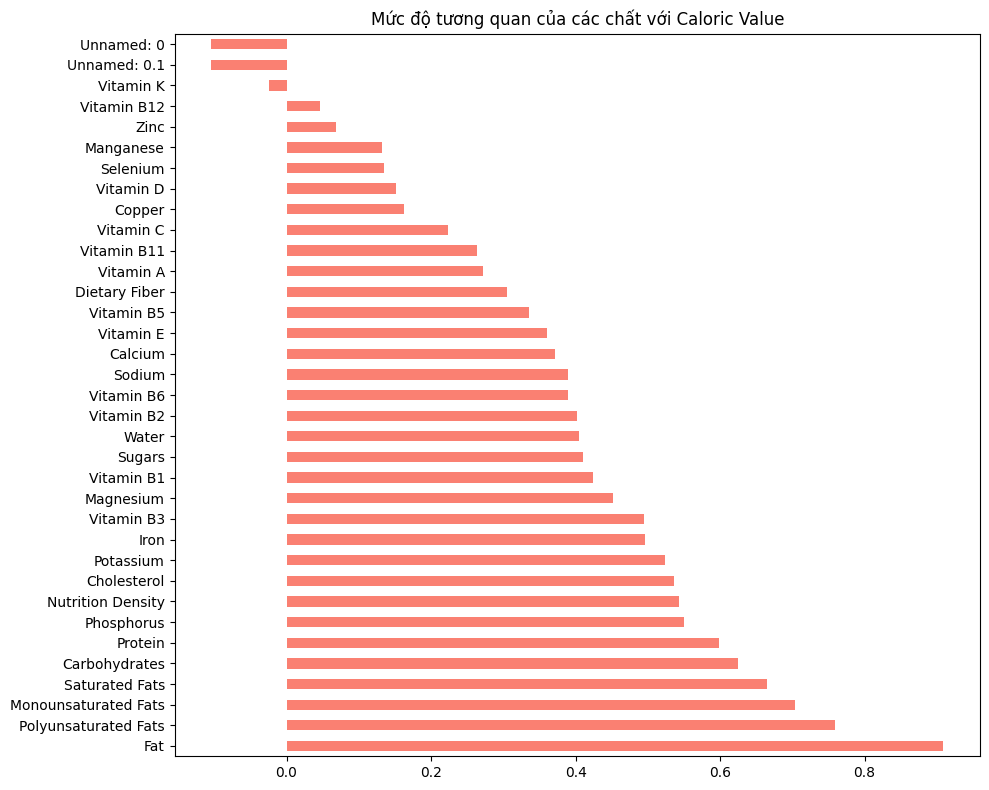

In [31]:
# 3.4b. Tương quan Pearson với biến mục tiêu
target_corr = df[continuous_cols].corr()[CONFIG['TARGET_COL']].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
target_corr.drop(CONFIG['TARGET_COL']).plot(kind='barh', color='salmon')
plt.title(f"Mức độ tương quan của các chất với {CONFIG['TARGET_COL']}")
save_fig("03_target_correlation")
plt.show()

##3.5a: Violin Plot (Theo nhóm Calo)

/tmp/ipykernel_36074/2850245975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Calo_Group', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_36074/2850245975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Calo_Group', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_36074/2850245975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Calo_Group', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_36074/2850245975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprec

Đang lưu biểu đồ: 03_violin_by_class...


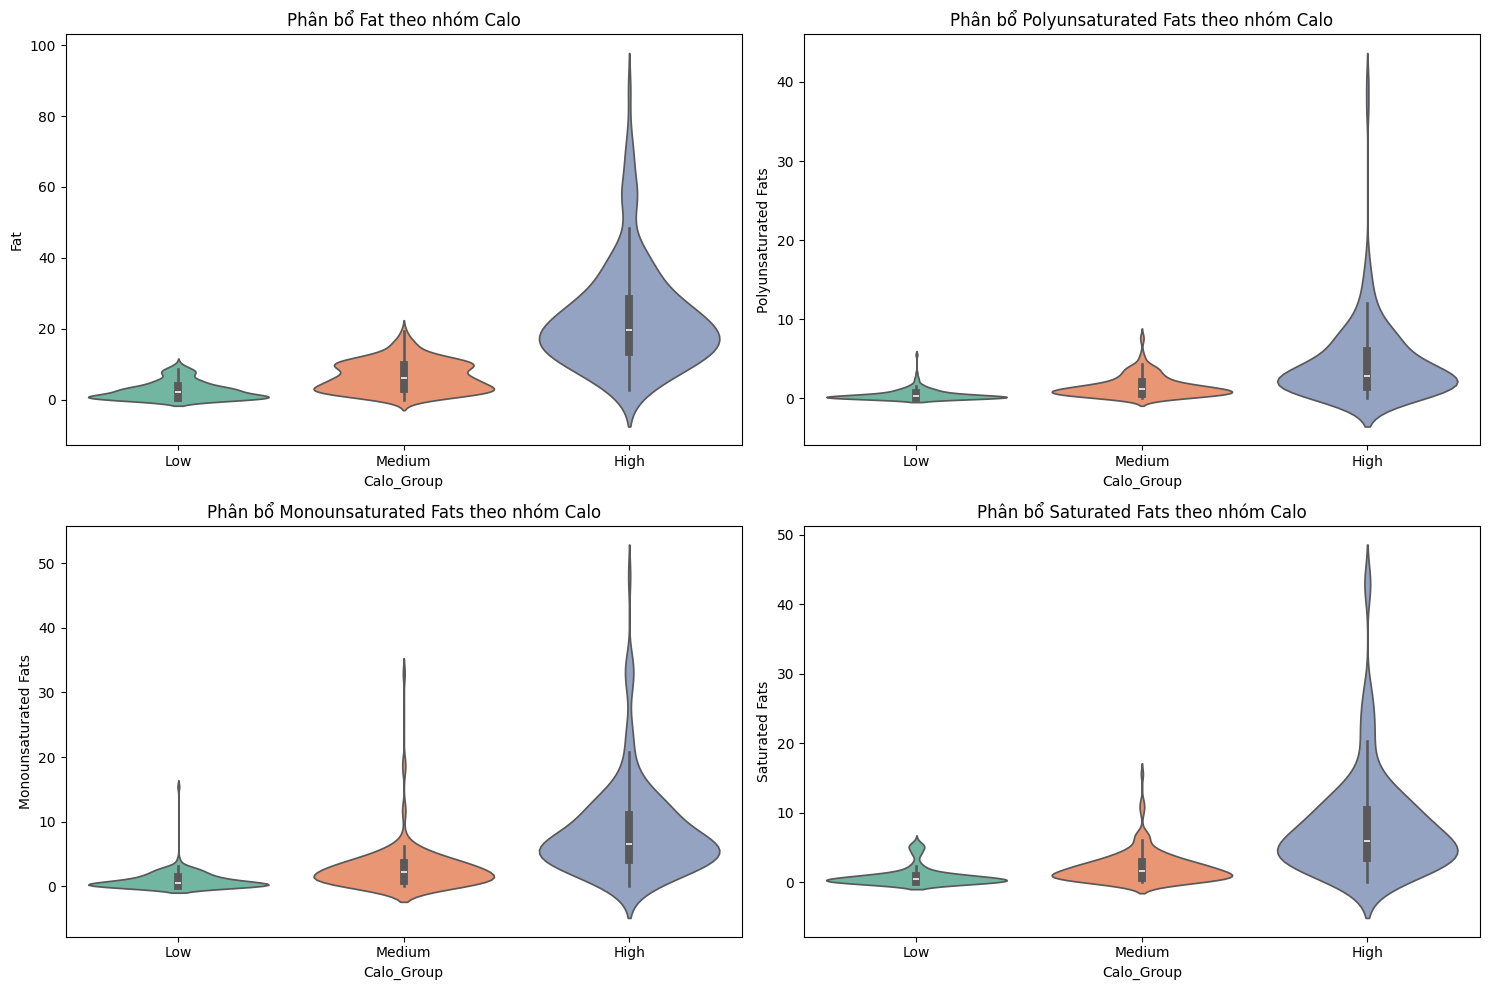

In [32]:
# 3.5a. Chia Calo thành 3 nhóm (Thấp, Trung bình, Cao) để vẽ Violin
df['Calo_Group'] = pd.qcut(df[CONFIG['TARGET_COL']], q=3, labels=['Low', 'Medium', 'High'])

important_features = target_corr.index[1:5] # Lấy 4 chất tương quan nhất với Calo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(important_features):
    sns.violinplot(x='Calo_Group', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f"Phân bổ {col} theo nhóm Calo")

save_fig("03_violin_by_class")
plt.show()

##3.5b: Stacked Bar (Categorical x Target)

Đang lưu biểu đồ: 03_cat_target_structure...


<Figure size 1200x600 with 0 Axes>

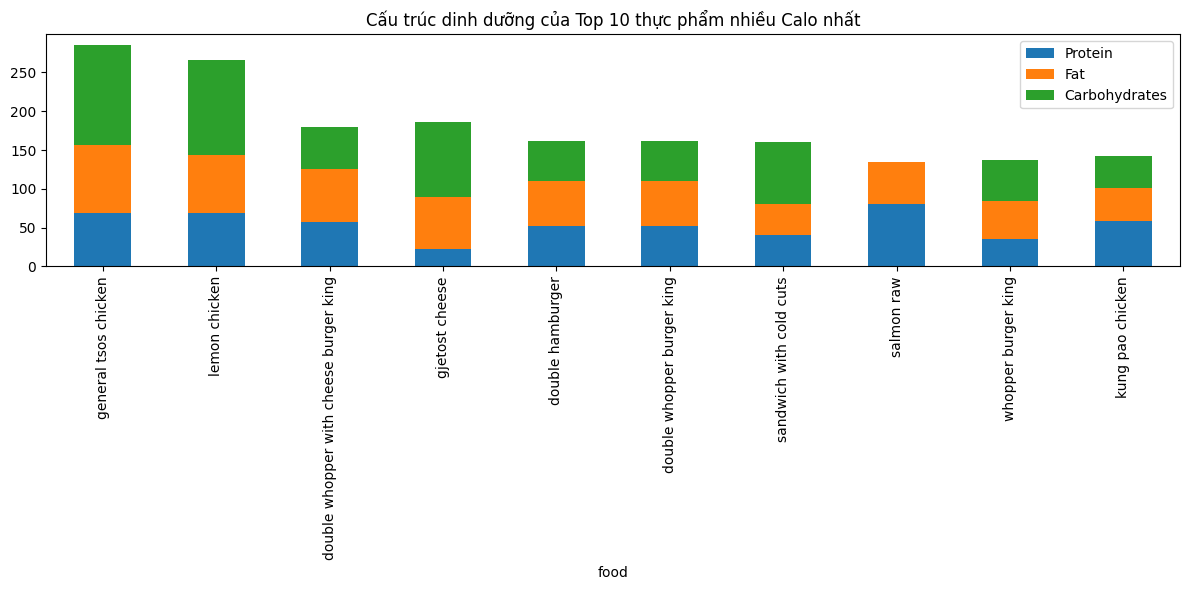

In [33]:
# 3.5b. Vì đây là Regression, ta dùng binned target
plt.figure(figsize=(12, 6))
# Giả sử ta xem xét cột 'Group' nếu có, hoặc dùng 10 món đầu tiên
top_foods = df.nlargest(10, CONFIG['TARGET_COL'])
top_foods.set_index('food')[['Protein', 'Fat', 'Carbohydrates']].plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Cấu trúc dinh dưỡng của Top 10 thực phẩm nhiều Calo nhất")
save_fig("03_cat_target_structure")
plt.show()

##3.5c: Scatter + Trend line

Đang lưu biểu đồ: 03_scatter_top_features...


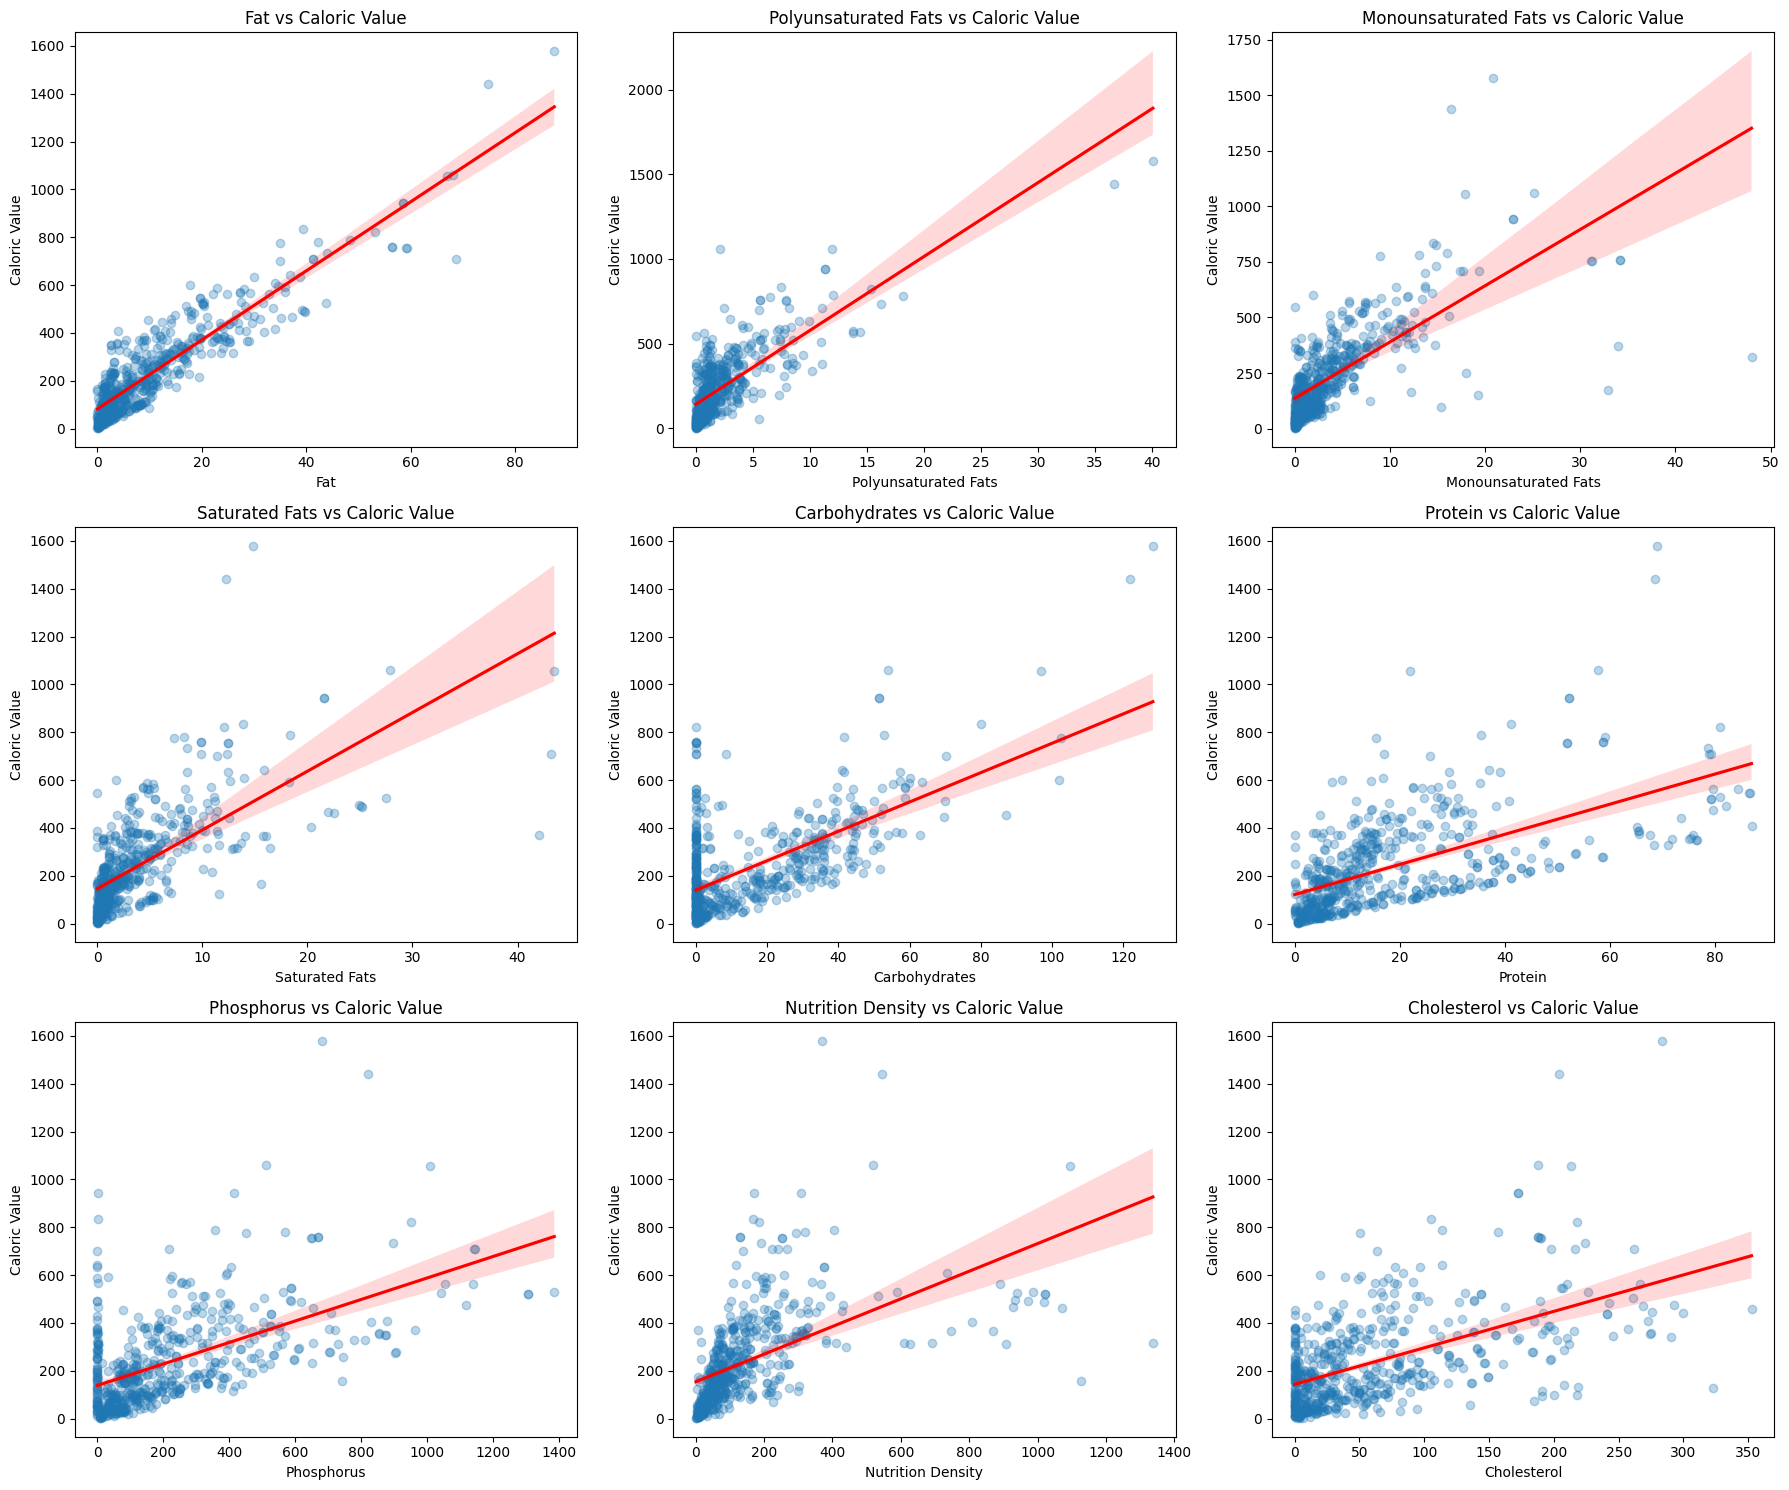

In [34]:
# 3.5c. Top 9 features vs Target
top_9 = target_corr.index[1:10]
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(top_9):
    sns.regplot(x=col, y=CONFIG['TARGET_COL'], data=df, ax=axes[i],
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    axes[i].set_title(f"{col} vs {CONFIG['TARGET_COL']}")

save_fig("03_scatter_top_features")
plt.show()

##3.6: Pairplot (Top 5 features)

Đang lưu biểu đồ: 03_pairplot...


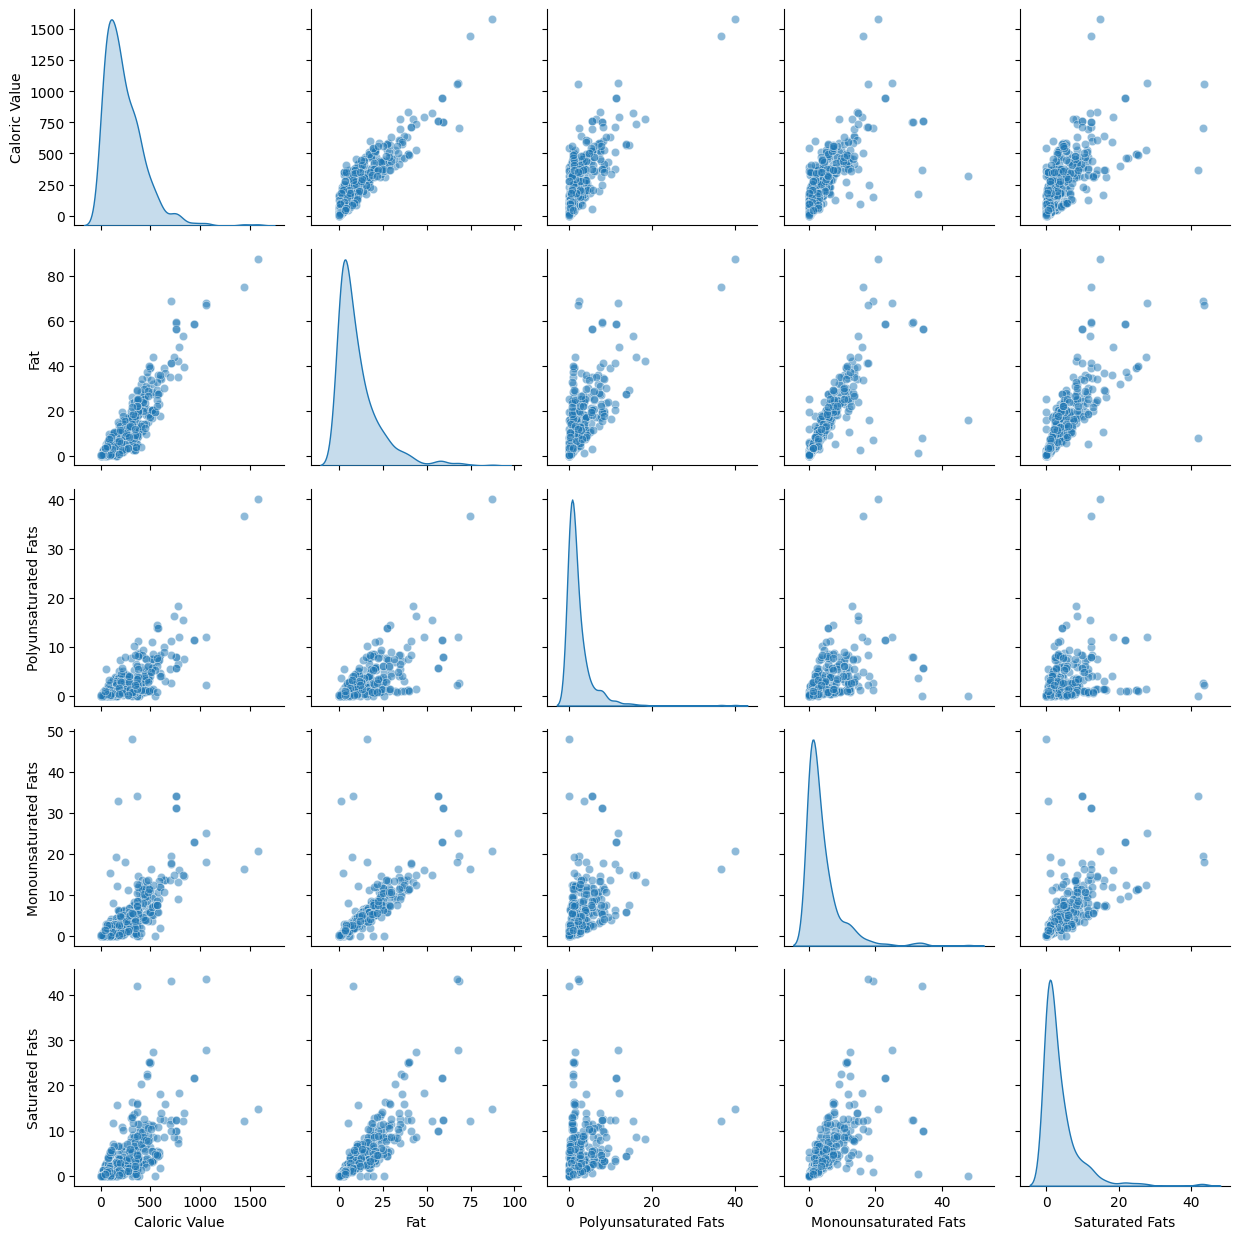

In [35]:
# 3.6. Pairplot cho 5 chất quan trọng nhất
top_5 = target_corr.index[:5].tolist()
sns.pairplot(df[top_5].sample(min(2000, len(df))), diag_kind='kde', plot_kws={'alpha':0.5})
save_fig("03_pairplot")
plt.show()

##3.7: Time Series Check

In [36]:
# 3.7. Kiểm tra dữ liệu thời gian (Thường không có trong data thực phẩm)
dt_cols = df.select_dtypes(include=['datetime']).columns
if len(dt_cols) > 0:
    print(f"Phát hiện cột thời gian: {dt_cols}")
    # Code vẽ time series ở đây
else:
    print("Dữ liệu không chứa thành phần thời gian. Bỏ qua bước 3.7.")

Dữ liệu không chứa thành phần thời gian. Bỏ qua bước 3.7.


##3.8: Auto TODO list cho Bước 4

In [39]:
# 3.8. Tự động quét và lập danh sách việc cần làm
todo = []
if outlier_df['Outlier %'].max() > 5:
    todo.append("Xử lý Outliers cho các cột tô đỏ ở bước 3.2b")
# Chỉ tính skewness trên các cột số
if df.select_dtypes(include=np.number).skew().abs().max() > 1:
    todo.append("Thực hiện Log Transformation cho các cột bị lệch (Skewed)")
if high_corr.any():
    todo.append("Cân nhắc loại bỏ các cột bị đa cộng tuyến (Multicollinearity)")

todo_df = pd.DataFrame({'Công việc': todo})
todo_df.to_csv(os.path.join(CONFIG["EXPORT_DIR"], "03_eda_todo.csv"), index=False)
display(todo_df)

,Công việc
0,Xử lý Outliers cho các cột tô đỏ ở bước 3.2b
1,Thực hiện Log Transformation cho các cột bị lệ...
2,Cân nhắc loại bỏ các cột bị đa cộng tuyến (Mul...


#4.Làm sạch - Tiền xử lý dữ liệu

##4.1: Snapshot ban đầu & Load TODO

In [40]:
# 4.1. Hàm chụp ảnh trạng thái dữ liệu để so sánh
def snapshot(df, step_name):
    print(f"\n[SNAPSHOT] {step_name}")
    print(f"- Shape: {df.shape}")
    print(f"- Missing: {df.isnull().sum().sum()}")
    print(f"- Duplicates: {df.duplicated().sum()}")

snapshot(df, "Bắt đầu Bước 4")

# Load TODO từ bước 3 (nếu có file)
todo_path = os.path.join(CONFIG["EXPORT_DIR"], "03_eda_todo.csv")
if os.path.exists(todo_path):
    display(pd.read_csv(todo_path))


[SNAPSHOT] Bắt đầu Bước 4
- Shape: (551, 38)
- Missing: 0
- Duplicates: 0


,Công việc
0,Xử lý Outliers cho các cột tô đỏ ở bước 3.2b
1,Thực hiện Log Transformation cho các cột bị lệ...
2,Cân nhắc loại bỏ các cột bị đa cộng tuyến (Mul...


##4.2: Chuẩn hóa tên cột

In [41]:
import re

# 4.2. Lowercase, bỏ ký tự đặc biệt, space -> underscore
original_target = CONFIG['TARGET_COL']
df.columns = [re.sub(r'\W+', '_', col.strip().lower()).strip('_') for col in df.columns]

# Cập nhật lại CONFIG['TARGET_COL'] vì tên đã bị đổi
new_target = re.sub(r'\W+', '_', original_target.strip().lower()).strip('_')
CONFIG['TARGET_COL'] = new_target

print(f"Target mới: {CONFIG['TARGET_COL']}")
display(df.columns.tolist())

Target mới: caloric_value


['unnamed_0_1',
 'unnamed_0',
 'food',
 'caloric_value',
 'fat',
 'saturated_fats',
 'monounsaturated_fats',
 'polyunsaturated_fats',
 'carbohydrates',
 'sugars',
 'protein',
 'dietary_fiber',
 'cholesterol',
 'sodium',
 'water',
 'vitamin_a',
 'vitamin_b1',
 'vitamin_b11',
 'vitamin_b12',
 'vitamin_b2',
 'vitamin_b3',
 'vitamin_b5',
 'vitamin_b6',
 'vitamin_c',
 'vitamin_d',
 'vitamin_e',
 'vitamin_k',
 'calcium',
 'copper',
 'iron',
 'magnesium',
 'manganese',
 'phosphorus',
 'potassium',
 'selenium',
 'zinc',
 'nutrition_density',
 'calo_group']

##4.3: Drop Duplicates

In [42]:
# 4.3. Xóa dòng trùng lặp và reset index
if df.duplicated().sum() > 0:
    print("Ví dụ dòng trùng lặp trước khi xóa:")
    display(df[df.duplicated()].head(2))
    df = df.drop_duplicates().reset_index(drop=True)
    print("Đã xóa trùng lặp.")
snapshot(df, "Sau khi xóa trùng lặp")


[SNAPSHOT] Sau khi xóa trùng lặp
- Shape: (551, 38)
- Missing: 0
- Duplicates: 0


##4.4a: Auto-detect Object -> Numeric

In [43]:
# 4.4a. Xử lý dấu phẩy, khoảng trắng và ép kiểu số
for col in df.select_dtypes(include=['object']).columns:
    # Thử parse thử 70% dữ liệu, nếu thành công thì ép kiểu toàn bộ
    converted = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
    if converted.notnull().sum() > len(df) * 0.7:
        df[col] = converted
        print(f"Đã chuyển đổi cột '{col}' sang kiểu số.")

##4.4b: Parse Datetime

In [44]:
# 4.4b. Tự động nhận diện cột thời gian
for col in df.select_dtypes(include=['object']).columns:
    try:
        df[col] = pd.to_datetime(df[col])
        print(f"Đã parse cột '{col}' sang Datetime.")
    except:
        continue

/tmp/ipykernel_36074/4073356489.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])


##4.4c: Downcast Binary -> Int8

In [45]:
# 4.4c. Tiết kiệm RAM cho các cột chỉ có 2 giá trị (0/1)
for col in df.select_dtypes(include=['number']).columns:
    if df[col].nunique() == 2:
        df[col] = df[col].astype(np.int8)
        print(f"Downcast cột '{col}' sang Int8.")

##4.5a: Phân loại cột Missing

In [46]:
# 4.5a. Phân loại dựa trên ngưỡng THRESH_DROP = 50%
THRESH_DROP = 0.5
missing_pct = df.isnull().sum() / len(df)

drop_cols = missing_pct[missing_pct > THRESH_DROP].index.tolist()
high_missing = missing_pct[(missing_pct <= THRESH_DROP) & (missing_pct > 0.2)].index.tolist()
low_missing = missing_pct[(missing_pct <= 0.2) & (missing_pct > 0)].index.tolist()

print(f"🔴 Drop (>50%): {drop_cols}")
print(f"🟡 High (20-50%): {high_missing}")
print(f"🟢 Low (<20%): {low_missing}")

🔴 Drop (>50%): []
🟡 High (20-50%): []
🟢 Low (<20%): []


##4.5b: Drop cột Missing > 50%

In [47]:
# 4.5b. Thực thi xóa cột
df = df.drop(columns=drop_cols)
print(f"Đã xóa {len(drop_cols)} cột thiếu quá nhiều.")

Đã xóa 0 cột thiếu quá nhiều.


##4.5c: Drop row missing Target

In [48]:
# 4.5c. Ưu tiên cao nhất: Xóa dòng không có nhãn mục tiêu
before = len(df)
df = df.dropna(subset=[CONFIG['TARGET_COL']]).reset_index(drop=True)
print(f"Đã xóa {before - len(df)} dòng thiếu cột Target.")

Đã xóa 0 dòng thiếu cột Target.


##4.5d: Impute Numerical

In [49]:
# 4.5d. Median cho Low, Median + Flag cho High
for col in df.select_dtypes(include=[np.number]).columns:
    if col in low_missing:
        df[col] = df[col].fillna(df[col].median())
    elif col in high_missing:
        df[f"{col}_was_missing"] = df[col].isnull().astype(np.int8)
        df[col] = df[col].fillna(df[col].median())
print("Đã hoàn tất Impute cột số.")

Đã hoàn tất Impute cột số.


##4.5e: Impute Categorical

In [50]:
# 4.5e. Mode cho Low, 'unknown' cho High
for col in df.select_dtypes(include=['object']).columns:
    if col in low_missing:
        df[col] = df[col].fillna(df[col].mode()[0])
    elif col in high_missing:
        df[col] = df[col].fillna('unknown')
print("Đã hoàn tất Impute cột chữ.")

Đã hoàn tất Impute cột chữ.


##4.6a: Lên kế hoạch Outlier

In [54]:
# 4.6a. Tự động phát hiện cột cần Clip (Winsorize)
AUTO_CLIP = True
cols_to_clip = []
if AUTO_CLIP:
    for col in df.select_dtypes(include=[np.number]).columns:
        # Nếu có outlier > 5% (từ bước 3)
        Q1, Q3 = df[col].quantile(0.05), df[col].quantile(0.95)
        cols_to_clip.append(col)
print(f"Kế hoạch: Clip 5%-95% cho {len(cols_to_clip)} cột.")

Kế hoạch: Clip 5%-95% cho 36 cột.


## 4.6b: Thực thi Outlier (Winsorize/Log1p)

In [55]:
# 4.6b. Thực hiện xử lý Outlier và Skewness
for col in cols_to_clip:
    # Winsorize (Clip)
    lower, upper = df[col].quantile(0.05), df[col].quantile(0.95)
    df[col] = df[col].clip(lower, upper)

    # Log transformation nếu cột vẫn bị lệch (skew > 1)
    if df[col].skew() > 1:
        df[col] = np.log1p(df[col])
        print(f"Đã Log1p cột '{col}'")

Đã Log1p cột 'fat'
Đã Log1p cột 'saturated_fats'
Đã Log1p cột 'monounsaturated_fats'
Đã Log1p cột 'polyunsaturated_fats'
Đã Log1p cột 'sugars'
Đã Log1p cột 'protein'
Đã Log1p cột 'dietary_fiber'
Đã Log1p cột 'cholesterol'
Đã Log1p cột 'vitamin_a'
Đã Log1p cột 'vitamin_b1'
Đã Log1p cột 'vitamin_b11'
Đã Log1p cột 'vitamin_b2'
Đã Log1p cột 'vitamin_b3'
Đã Log1p cột 'vitamin_b5'
Đã Log1p cột 'vitamin_b6'
Đã Log1p cột 'vitamin_c'
Đã Log1p cột 'vitamin_d'
Đã Log1p cột 'vitamin_e'
Đã Log1p cột 'vitamin_k'
Đã Log1p cột 'calcium'
Đã Log1p cột 'copper'
Đã Log1p cột 'magnesium'
Đã Log1p cột 'manganese'
Đã Log1p cột 'phosphorus'
Đã Log1p cột 'potassium'
Đã Log1p cột 'selenium'
Đã Log1p cột 'zinc'
Đã Log1p cột 'nutrition_density'


##4.7: Encode Categorical

In [56]:
# 4.7. Encode thông minh tránh Data Leakage
for col in df.select_dtypes(include=['object']).columns:
    if col == 'food': continue # Giữ lại cột tên để hiển thị

    n_unique = df[col].nunique()
    if n_unique <= 10:
        # One-Hot Encoding thủ công
        df = pd.get_dummies(df, columns=[col], prefix=col)
    else:
        # Frequency Encoding
        freq = df[col].value_counts(normalize=True)
        df[col] = df[col].map(freq)
print("Đã hoàn tất Encoding.")

Đã hoàn tất Encoding.


##4.8: 5 Checks Pass/Fail

1. No Nulls: ✅ PASS
2. No Duplicates: ✅ PASS
3. Target Exists: ✅ PASS
4. All Numeric: ❌ FAIL
5. Shape OK: ✅ PASS


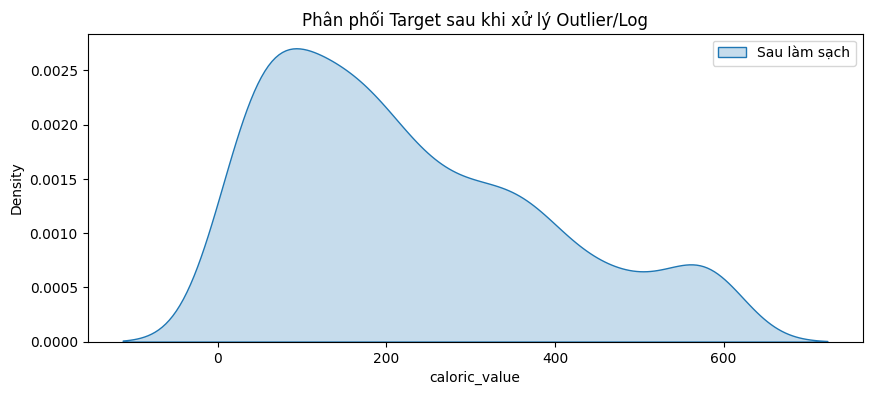

In [57]:
# 4.8. Kiểm tra cuối cùng
checks = {
    "1. No Nulls": df.isnull().sum().sum() == 0,
    "2. No Duplicates": df.duplicated().sum() == 0,
    "3. Target Exists": CONFIG['TARGET_COL'] in df.columns,
    "4. All Numeric": df.drop(columns=['food']).select_dtypes(exclude=[np.number]).empty,
    "5. Shape OK": df.shape[0] > 0
}
for k, v in checks.items():
    print(f"{k}: {'✅ PASS' if v else '❌ FAIL'}")

# So sánh phân phối trước/sau (Ví dụ cột Target)
plt.figure(figsize=(10, 4))
sns.kdeplot(df[CONFIG['TARGET_COL']], label='Sau làm sạch', fill=True)
plt.title("Phân phối Target sau khi xử lý Outlier/Log")
plt.legend()
plt.show()

##4.9: Lưu dữ liệu sạch

In [58]:
# 4.9. Lưu file và báo cáo
clean_data_path = os.path.join(CONFIG["EXPORT_DIR"], "df_cleaned.csv")
df.to_csv(clean_data_path, index=False)

cleaning_report = {
    "final_shape": df.shape,
    "features": df.columns.tolist(),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}
joblib.dump(cleaning_report, os.path.join(CONFIG["EXPORT_DIR"], "04_cleaning_report.json"))

print(f"Đã lưu dữ liệu sạch tại: {clean_data_path}")

Đã lưu dữ liệu sạch tại: ./exports/df_cleaned.csv


#5.Feature engineering và chuẩn bị model

##5.1: Snapshot & Target Distribution

Shape hiện tại: (551, 38)


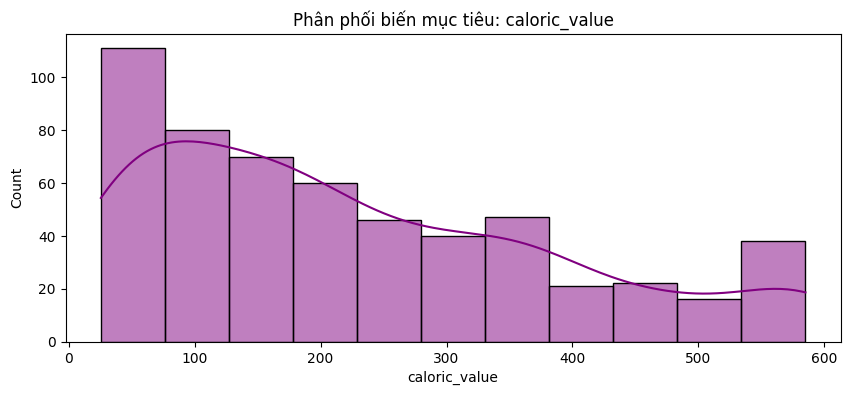

In [59]:
# 5.1. Kiểm tra trạng thái cuối cùng trước khi tách dữ liệu
print(f"Shape hiện tại: {df.shape}")
plt.figure(figsize=(10, 4))
sns.histplot(df[CONFIG['TARGET_COL']], kde=True, color='purple')
plt.title(f"Phân phối biến mục tiêu: {CONFIG['TARGET_COL']}")
plt.show()

## 5.2a: Feature số học (Ratios & Log)

In [60]:
# 5.2a. Tạo các chỉ số thông minh (Domain Knowledge)
# Ví dụ: Tỷ lệ Protein trên mỗi Calo (Mật độ dinh dưỡng)
df['protein_per_calorie'] = df['protein'] / (df[CONFIG['TARGET_COL']] + 1e-9)
df['fat_per_calorie'] = df['fat'] / (df[CONFIG['TARGET_COL']] + 1e-9)

# Tạo thêm biến tương tác (Interaction) giữa các chất chính
df['carb_protein_ratio'] = df['carbohydrates'] / (df['protein'] + 1e-9)

print("Đã tạo thêm các Feature tỷ lệ dinh dưỡng.")

Đã tạo thêm các Feature tỷ lệ dinh dưỡng.


##5.2b: Feature thời gian (Nếu có)

In [61]:
# 5.2b. Xử lý thời gian (Nếu dữ liệu thực phẩm có ngày cập nhật)
dt_cols = df.select_dtypes(include=['datetime']).columns
if len(dt_cols) > 0:
    for col in dt_cols:
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek
    df = df.drop(columns=dt_cols)
    print("Đã trích xuất đặc trưng thời gian.")
else:
    print("Không có cột thời gian. Bỏ qua bước 5.2b.")

Không có cột thời gian. Bỏ qua bước 5.2b.


##5.2c: Feature Categorical (Binning)

In [62]:
# 5.2c. Phân nhóm Calo (Chỉ dùng để tạo Feature bổ trợ)
df['energy_level'] = pd.qcut(df[CONFIG['TARGET_COL']], q=4, labels=[1, 2, 3, 4]).astype(int)
print("Đã thực hiện Binning cho mức năng lượng.")

Đã thực hiện Binning cho mức năng lượng.


##5.3: Tách X / y & Phân loại cột

In [63]:
# 5.3. Xác định các cột cần loại bỏ (ID, Tên món, hoặc cột trùng lặp)
DROP_COLS = ['food', 'unnamed_0', 'group'] # Tên cột có thể khác tùy data của bạn

X = df.drop(columns=[CONFIG['TARGET_COL']] + [c for c in DROP_COLS if c in df.columns])
y = df[CONFIG['TARGET_COL']]

NUM_COLS = X.select_dtypes(include=[np.number]).columns.tolist()
CAT_COLS = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Features: {X.shape[1]} cột | Target: {CONFIG['TARGET_COL']}")
print(f"Số cột số: {len(NUM_COLS)} | Số cột chữ: {len(CAT_COLS)}")

Features: 39 cột | Target: caloric_value
Số cột số: 38 | Số cột chữ: 1


##5.4: Train / Val / Test Split

In [64]:
# 5.4. Chia dữ liệu 3 phần: 70% Train, 15% Val, 15% Test
# Vì là Regression, ta stratify bằng cách binning y tạm thời
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=CONFIG['RANDOM_STATE'], stratify=y_binned
)

# Chia tiếp Train_full thành Train và Val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=CONFIG['RANDOM_STATE']
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 385 | Val: 83 | Test: 83


##5.5: sklearn Pipeline + ColumnTransformer

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# 5.5. Xây dựng quy trình xử lý tự động
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', pd.get_dummies) # Lưu ý: Trong Pipeline thực tế nên dùng OneHotEncoder của sklearn
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, NUM_COLS)
    # ('cat', cat_transformer, CAT_COLS) # Bỏ comment nếu có cột chữ
])

# QUAN TRỌNG: Chỉ fit trên X_train để tránh Data Leakage
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Pipeline đã được fit và transform dữ liệu thành công.")

Pipeline đã được fit và transform dữ liệu thành công.


##5.6: Feature Importance (Sơ bộ)

Đang lưu biểu đồ: 05_feature_importance...


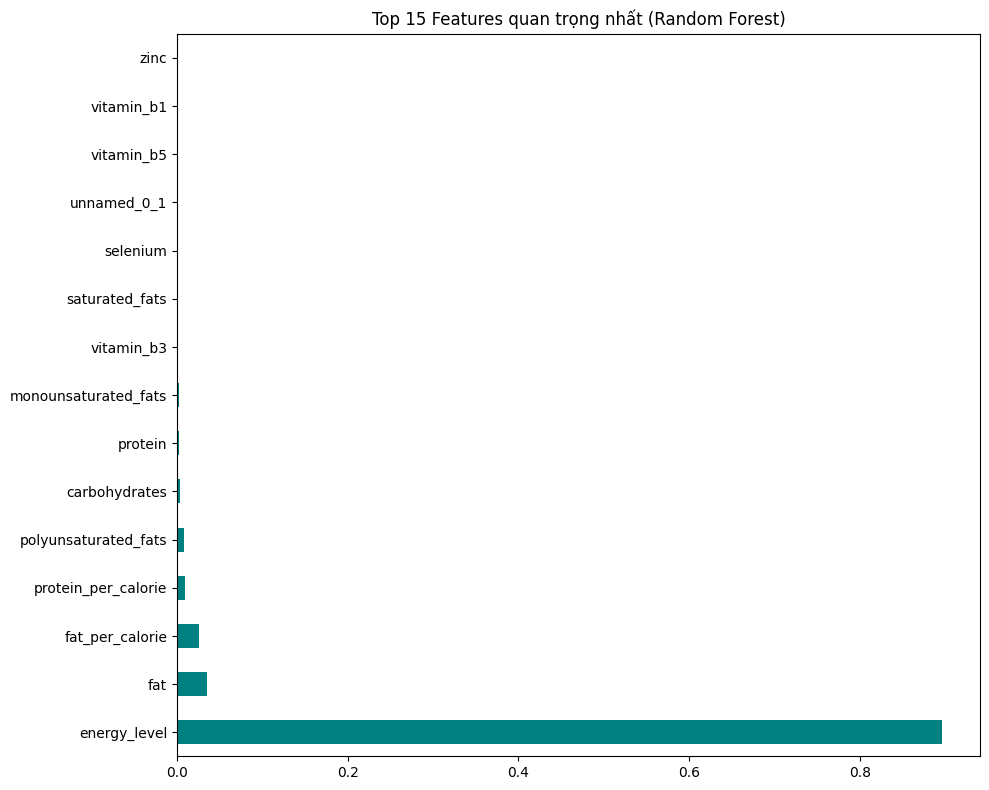

In [66]:
from sklearn.ensemble import RandomForestRegressor

# 5.6. Dùng Random Forest để xem chất nào quan trọng nhất
rf_selector = RandomForestRegressor(n_estimators=50, random_state=42)
rf_selector.fit(X_train_proc, y_train)

importances = rf_selector.feature_importances_
feat_importances = pd.Series(importances, index=NUM_COLS).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_importances.head(15).plot(kind='barh', color='teal')
plt.title("Top 15 Features quan trọng nhất (Random Forest)")
save_fig("05_feature_importance")
plt.show()

##5.7: Xử lý Skewed Target

In [68]:
# 5.7. Kiểm tra độ lệch của Target và Log-transform nếu cần
if y_train.skew() > 1:
    print(f"Target bị lệch dương ({y_train.skew():.2f}). Áp dụng Log Transformation.")
    y_train_log = np.log1p(y_train)
    y_val_log = np.log1p(y_val)
    y_test_log = np.log1p(y_test)
else:
    y_train_log, y_val_log, y_test_log = y_train, y_val, y_test
    print("Target phân phối ổn định. Không cần biến đổi.")

Target phân phối ổn định. Không cần biến đổi.


##5.8: Sanity Check

In [69]:
# 5.8. Kiểm tra cuối cùng trước khi Train Model
assert not np.isnan(X_train_proc).any(), "Lỗi: Vẫn còn giá trị NaN trong X_train!"
assert X_train_proc.shape[0] == y_train.shape[0], "Lỗi: Lệch số lượng dòng giữa X và y!"

print("✅ Mọi kiểm tra đều vượt qua. Dữ liệu đã sẵn sàng cho Bước 6.")

✅ Mọi kiểm tra đều vượt qua. Dữ liệu đã sẵn sàng cho Bước 6.


##5.9: Lưu Preprocessor & Metadata

In [70]:
# 5.9. Lưu trữ để dùng cho Web App
joblib.dump(preprocessor, os.path.join(CONFIG["EXPORT_DIR"], 'preprocessor.pkl'))

feature_meta = {
    'num_cols': NUM_COLS,
    'cat_cols': CAT_COLS,
    'target': CONFIG['TARGET_COL'],
    'feature_names_out': NUM_COLS # Nếu có OneHot thì danh sách này sẽ dài hơn
}
import json
with open(os.path.join(CONFIG["EXPORT_DIR"], 'feature_meta.json'), 'w') as f:
    json.dump(feature_meta, f)

print("Đã lưu Preprocessor và Metadata.")

Đã lưu Preprocessor và Metadata.


# 6.Model / Phân tích kết quả và Export

##6.1: Load Data & Metadata

In [71]:
# 6.1. Khôi phục dữ liệu từ Bước 5 (Nếu chạy liên tục thì không cần load lại)
# Ở đây chúng ta sử dụng các biến đã có: X_train_proc, X_val_proc, X_test_proc, y_train, y_val, y_test
X_train_final = X_train_proc
X_val_final = X_val_proc
X_test_final = X_test_proc

feature_names = NUM_COLS # Lấy danh sách tên cột từ metadata Bước 5
print(f"Sẵn sàng huấn luyện với {X_train_final.shape[1]} đặc trưng.")

Sẵn sàng huấn luyện với 38 đặc trưng.


##6.2: Định nghĩa Model Candidates & Metric

In [72]:
# 6.2. Thiết lập danh sách các "ứng cử viên" và Metric đánh giá chính
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

MAIN_METRIC = 'r2' # R-squared: Đo lường mức độ giải thích của mô hình (0 -> 1)

##6.3: Cross-validation Baseline

Đang đánh giá Baseline Models...
- Linear Regression: 0.9286
- Ridge: 0.9290
- Lasso: 0.9291
- Random Forest: 0.9767
- XGBoost: 0.9866


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


- LightGBM: 0.9878
Thời gian thực thi: 34.2986 giây
Đang lưu biểu đồ: 06_model_comparison...


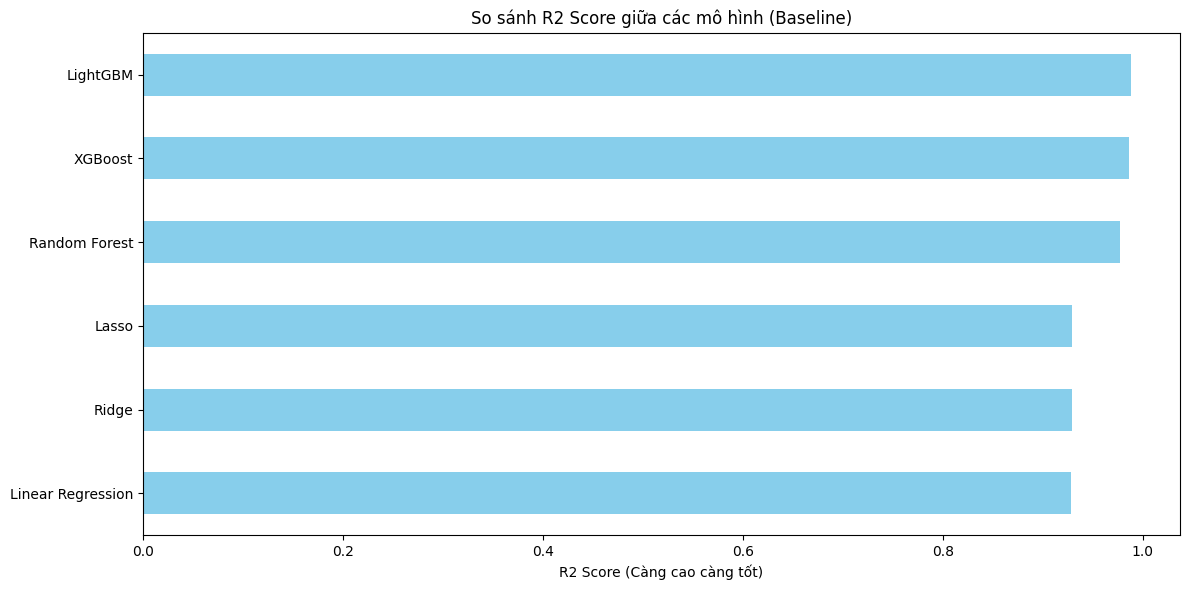


🏆 Model tốt nhất: LightGBM


In [73]:
# 6.3. So sánh hiệu năng các model bằng Cross-Validation (5-Fold)
results = {}
print("Đang đánh giá Baseline Models...")

with Timer():
    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train_final, y_train, cv=5, scoring=MAIN_METRIC)
        results[name] = cv_scores.mean()
        print(f"- {name}: {cv_scores.mean():.4f}")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
res_series = pd.Series(results).sort_values(ascending=True)
res_series.plot(kind='barh', color='skyblue')
plt.title('So sánh R2 Score giữa các mô hình (Baseline)')
plt.xlabel('R2 Score (Càng cao càng tốt)')
save_fig("06_model_comparison")
plt.show()

BEST_NAME = res_series.index[-1]
print(f"\n🏆 Model tốt nhất: {BEST_NAME}")

##6.4: RandomizedSearchCV (Hyperparameter Tuning)

In [74]:
# 6.4. Tinh chỉnh tham số cho Model tốt nhất (Ví dụ nếu là Random Forest hoặc XGBoost)
print(f"Đang tối ưu hóa {BEST_NAME}...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Lưu ý: Nếu BEST_NAME là XGBoost hoặc LGBM, param_grid cần điều chỉnh tên tham số tương ứng
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10, cv=3, scoring=MAIN_METRIC, n_jobs=-1, random_state=42
)

with Timer():
    search.fit(X_train_final, y_train)

best_model = search.best_estimator_
print(f"Thông số tối ưu: {search.best_params_}")

Đang tối ưu hóa LightGBM...
Thời gian thực thi: 62.9330 giây
Thông số tối ưu: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None}


##6.5: Đánh giá trên Validation Set

KẾT QUẢ TRÊN VALIDATION SET:
- R2 Score: 0.9897
- MAE: 12.3497
Đang lưu biểu đồ: 06_residuals_val...


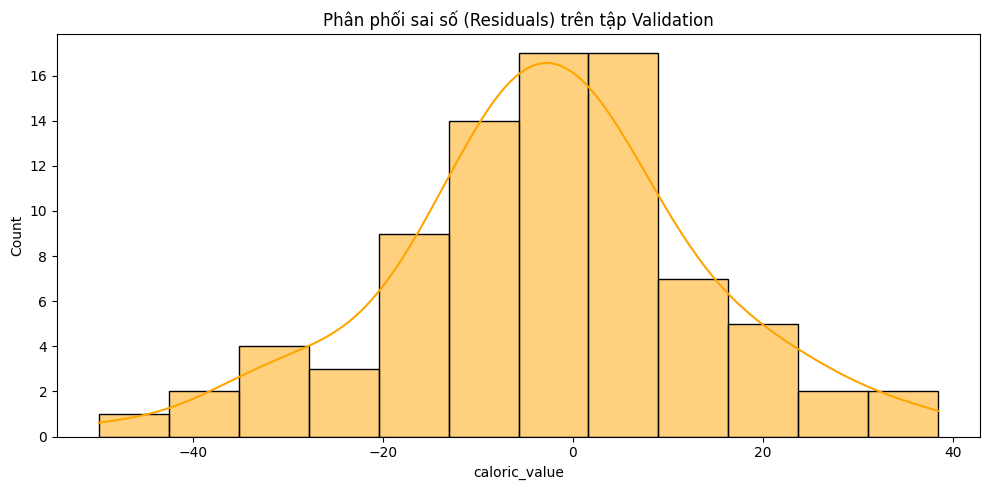

In [75]:
# 6.5. Kiểm tra độ chính xác trên tập Validation
y_val_pred = best_model.predict(X_val_final)

val_r2 = r2_score(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print(f"KẾT QUẢ TRÊN VALIDATION SET:")
print(f"- R2 Score: {val_r2:.4f}")
print(f"- MAE: {val_mae:.4f}")

# Vẽ biểu đồ Residuals (Sai số)
plt.figure(figsize=(10, 5))
residuals = y_val - y_val_pred
sns.histplot(residuals, kde=True, color='orange')
plt.title("Phân phối sai số (Residuals) trên tập Validation")
save_fig("06_residuals_val")
plt.show()

##6.6: Đánh giá cuối trên Test Set

Đang lưu biểu đồ: 06_actual_vs_predicted...


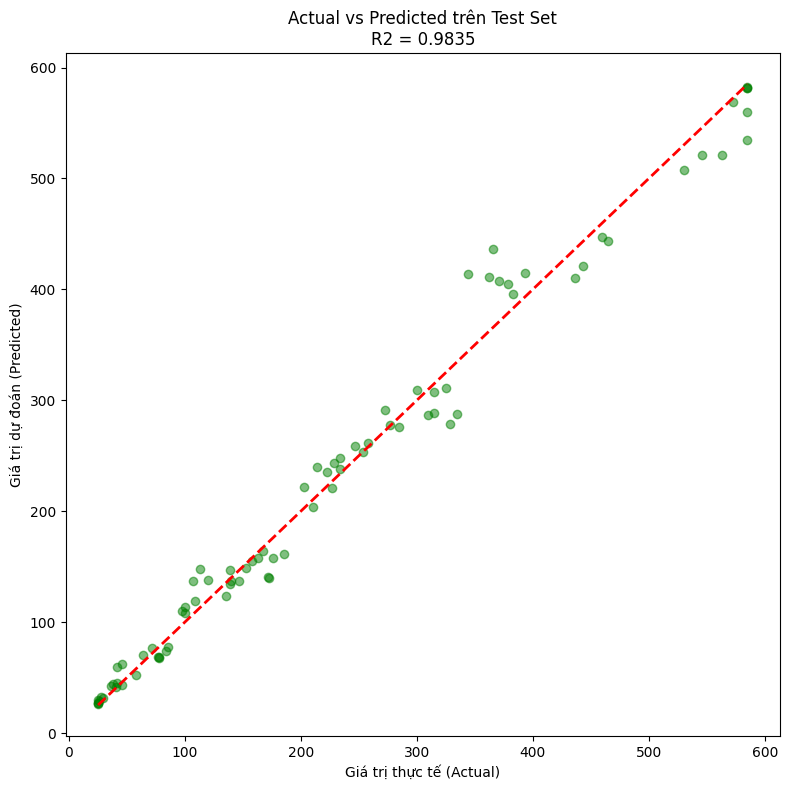

In [76]:
# 6.6. Đánh giá cuối cùng (Chỉ chạy 1 lần duy nhất)
y_test_pred = best_model.predict(X_test_final)

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá trị thực tế (Actual)')
plt.ylabel('Giá trị dự đoán (Predicted)')
plt.title(f'Actual vs Predicted trên Test Set\nR2 = {test_r2:.4f}')
save_fig("06_actual_vs_predicted")
plt.show()

##6.7: Feature Importance

Đang lưu biểu đồ: 06_feature_importance_final...


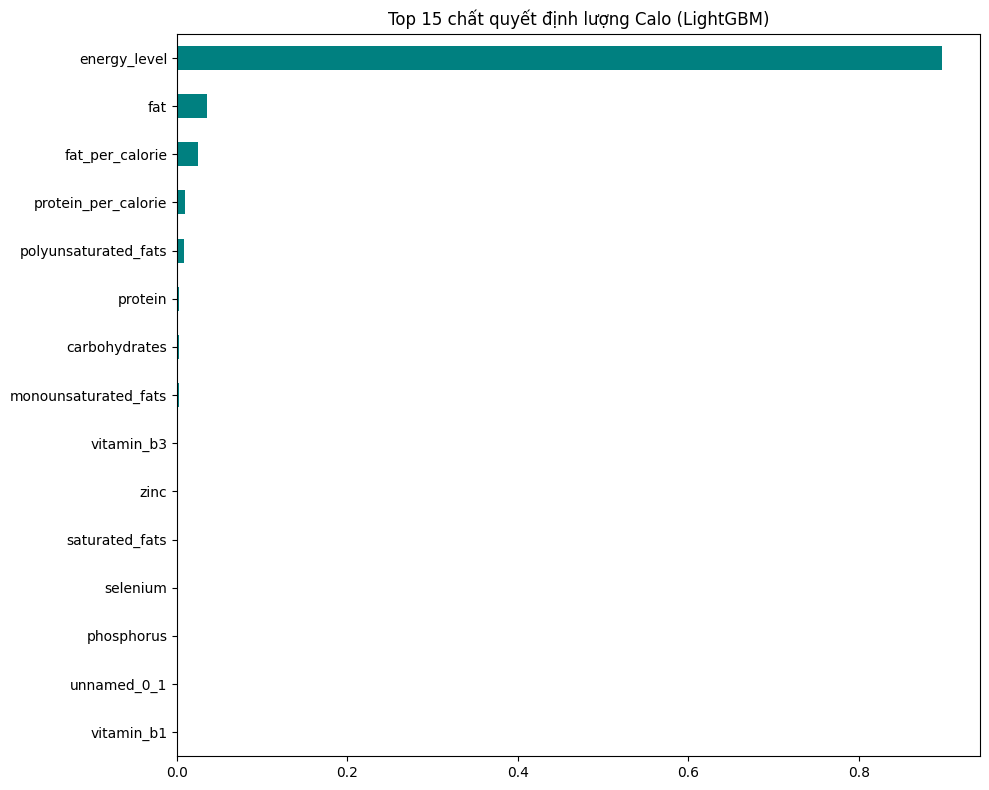

In [77]:
# 6.7. Trích xuất mức độ quan trọng của các chất dinh dưỡng
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(15).plot(kind='barh', color='teal')
plt.title(f"Top 15 chất quyết định lượng Calo ({BEST_NAME})")
plt.gca().invert_yaxis()
save_fig("06_feature_importance_final")
plt.show()

##6.8: SHAP (Giải thích mô hình)

Biểu đồ SHAP Summary (Tầm ảnh hưởng của các chất):
Đang lưu biểu đồ: 06_shap_summary...


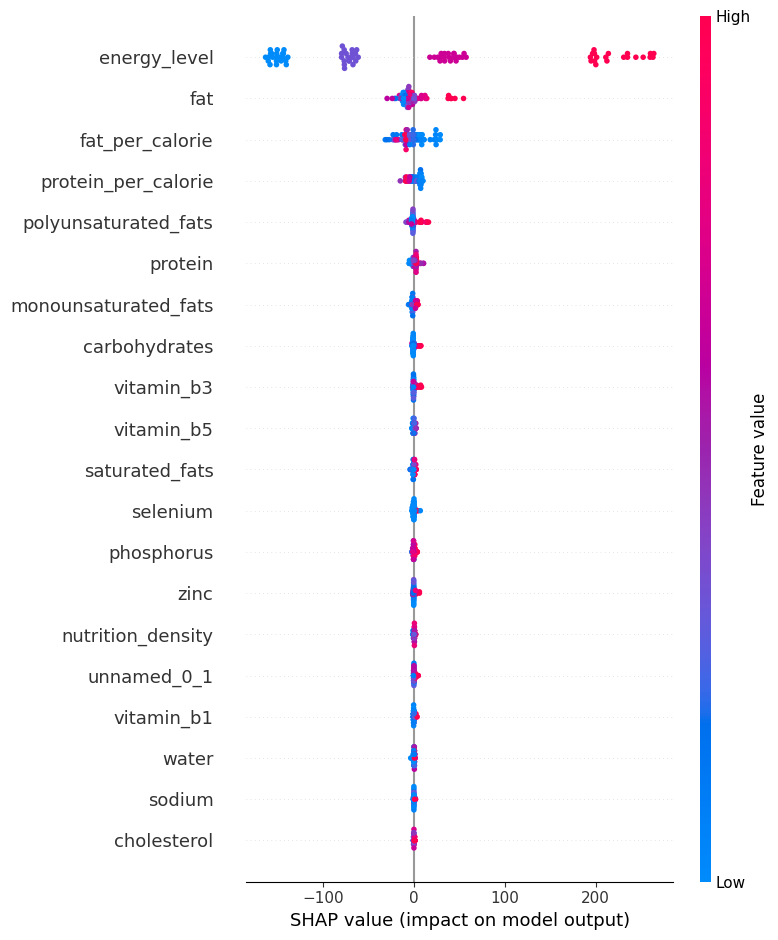

In [78]:
# 6.8. Sử dụng SHAP để giải thích từng dự đoán
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_final[:100])

print("Biểu đồ SHAP Summary (Tầm ảnh hưởng của các chất):")
shap.summary_plot(shap_values, X_test_final[:100], feature_names=feature_names, show=False)
save_fig("06_shap_summary")
plt.show()

## 6.9: Export Model & Report

In [79]:
# 6.9. Đóng gói mô hình kèm Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_path = os.path.join(CONFIG["EXPORT_DIR"], f"best_model_{timestamp}.pkl")

model_package = {
    'model': best_model,
    'metadata': {
        'r2_test': test_r2,
        'mae_test': test_mae,
        'features': feature_names,
        'timestamp': timestamp
    }
}
joblib.dump(model_package, model_path)

# Lưu kết quả dự đoán để đối chiếu
pd.DataFrame({'Actual': y_test, 'Predicted': y_test_pred}).to_csv(
    os.path.join(CONFIG["EXPORT_DIR"], f"predictions_{timestamp}.csv"), index=False
)

print(f"Đã xuất mô hình thành công: {model_path}")

Đã xuất mô hình thành công: ./exports/best_model_20260410_1230.pkl


##6.10: Tóm tắt kết quả

In [80]:
# 6.10. In bảng tổng kết đẹp mắt
summary_report = pd.DataFrame({
    'Thông số': ['Model chiến thắng', 'R2 Score (Test)', 'MAE (Test)', 'Thời gian xuất'],
    'Giá trị': [BEST_NAME, f"{test_r2:.4f}", f"{test_mae:.2f}", timestamp]
})

display(summary_report.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('background-color', '#4CAF50'), ('color', 'white')])
]))

print("\n--- CÁC FILE ĐÃ LƯU TRONG DRIVE ---")
!ls -lh {CONFIG["EXPORT_DIR"]}

,Thông số,Giá trị
0,Model chiến thắng,LightGBM
1,R2 Score (Test),0.9835
2,MAE (Test),15.53
3,Thời gian xuất,20260410_1230



--- CÁC FILE ĐÃ LƯU TRONG DRIVE ---
total 2.7M
-rw------- 1 root root  221 Apr 10 12:05 03_eda_todo.csv
-rw------- 1 root root  565 Apr 10 12:20 04_cleaning_report.json
-rw------- 1 root root 2.5M Apr 10 12:30 best_model_20260410_1230.pkl
-rw------- 1 root root 1.3K Apr 10 11:38 data_inspection_summary.csv
-rw------- 1 root root 291K Apr 10 12:20 df_cleaned.csv
-rw------- 1 root root 1.2K Apr 10 12:25 feature_meta.json
-rw------- 1 root root 2.0K Apr 10 12:30 predictions_20260410_1230.csv
-rw------- 1 root root 4.9K Apr 10 12:25 preprocessor.pkl
